<a href="https://colab.research.google.com/github/Gyuseo-stack/Statistics_DGS/blob/main/%F0%9F%8D%BF%F0%9F%A5%A4Netflix_Movies_and_TV_Shows_Clustering%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
bansodesandeep_netflix_movies_and_tv_shows_path = kagglehub.dataset_download('bansodesandeep/netflix-movies-and-tv-shows')

print('Data source import complete.')


100%|██████████| 1.18M/1.18M [00:00<00:00, 75.2MB/s]

Extracting files...
Data source import complete.


# <b><u> Project Title : Netflix Movies and TV Shows Clustering </u></b>

* **Project type** - Clustering, content based recommender system
* **Reference** - Amaan Vora https://www.kaggle.com/amaanvora

**Index:**
1. Problem statement
2. Importing the libraries and the dataset
3. Understanding data
4. Cleaning data
5. Exploratory data analysis
6. Data preprocessing
7. Clusters impelementation
8. Building content based recommender system
9. Conclusions
10. References

# **1. Problem statement:**

넷플릭스가 보유한 수많은 프로그램(쇼)을 효과적으로 군집화하는 것은 사용자 경험을 향상시키고, 구독자 이탈(churn)을 방지하기 위해 매우 중요하다.
### 프로그램들을 군집화함으로써 서로 유사하거나 다른 프로그램들을 파악할 수 있으며, 이를 바탕으로 사용자의 취향에 맞는 맞춤형 추천 시스템을 구축할 수 있다.
이 프로젝트의 목표는 넷플릭스 프로그램들을 유사한 특성을 가진 그룹(클러스터) 으로 분류하여, 같은 클러스터 내의 쇼들은 비슷하고, 다른 클러스터 간의 쇼들은 다르도록 만드는 것이다.

# **2. Importing the libraries and the dataset:**

In [2]:
# importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt

import warnings
warnings.filterwarnings('ignore')

from wordcloud import WordCloud, STOPWORDS
import re, string, unicodedata
import nltk
#import inflect
from bs4 import BeautifulSoup
from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import LancasterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import string
string.punctuation
nltk.download('omw-1.4')
from nltk.tokenize import TweetTokenizer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as shc

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

%matplotlib inline
sns.set()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [3]:
# reading data
# Attempting to read from the path specified by the user
file_path = '/content/Netflix_movies_and_tv_shows_clustering.csv'

original_df = pd.read_csv(file_path,index_col='show_id')
df = original_df.copy()

# **3. Understanding data:**

In [4]:
# top 5 rows
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [5]:
# dataframe shape
df.shape

(7787, 11)

**The dataset contains 7787 records and 11 attributes.**

In [6]:
# unique values in each column
df.nunique()

,0
type,2
title,7787
director,4049
cast,6831
country,681
date_added,1565
release_year,73
rating,14
duration,216
listed_in,492


## <b> 3.1. Attribute Information </b>
1. **show_id** : Unique ID for every Movie / Tv Show
2. **type** : Identifier - A Movie or TV Show
3. **title** : Title of the Movie / Tv Show
4. **director** : Director of the Movie
5. **cast** : Actors involved in the movie / show
6. **country** : Country where the movie / show was produced
7. **date_added** : Date it was added on Netflix
8. **release_year** : Actual Releaseyear of the movie / show
9. **rating** : TV Rating of the movie / show
10. **duration** : Total Duration - in minutes or number of seasons
11. **listed_in** : Genre
12. **description**: The Summary description

# **4. Cleaning data:**

## **4.1. Checking for duplicate records:**

In [7]:
# Checking for duplicate records
df.duplicated().value_counts()

,count
False,7787


**There are no duplicated records in the dataset.**

## **4.2. Checking for missing values and handling them:**

<Axes: ylabel='show_id'>

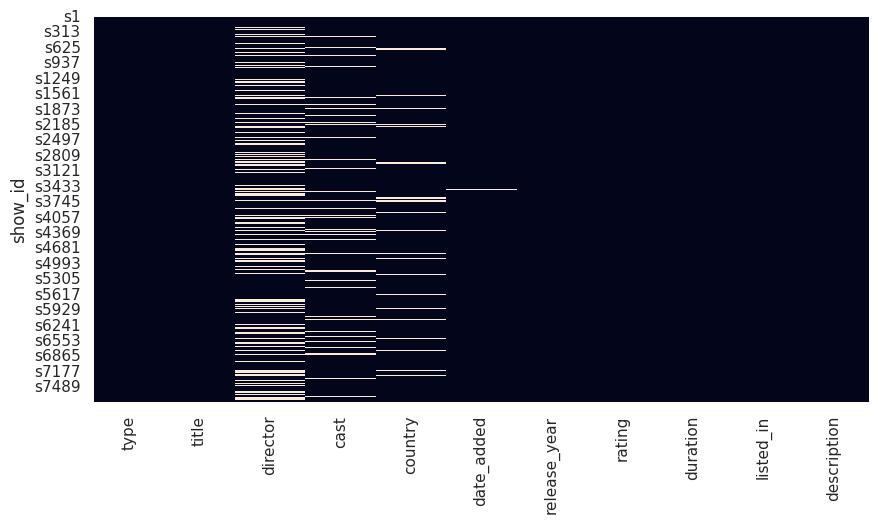

In [8]:
# Visualizing the missing values
# Checking Null Value by plotting Heatmap
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)

In [9]:
# Missing values in the dataset
df.isna().sum()

,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0
listed_in,0


**There are many missing values in director, cast, country, date_added, and rating columns.**

In [10]:
# Checking the unique values in each attribute of the dataset
df.nunique()

,0
type,2
title,7787
director,4049
cast,6831
country,681
date_added,1565
release_year,73
rating,14
duration,216
listed_in,492


- director, cast, country 속성에 결측치가 있을 경우, ‘Unknown’ 으로 대체할 수 있다.
- date_added 열에서 결측치가 있는 10개의 레코드 는 삭제할 수 있다.
- rating 속성의 결측치는 이 속성이 이산형변수이므로, 최빈값으로 대체할 수 있다.

In [11]:
# Handling the missing values
df[['director','cast','country']] = df[['director','cast','country']].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df.dropna(axis=0, inplace = True)

In [12]:
df.shape

(7777, 11)

We have successfully handled all the missing values in the dataset.

## **4.3. Country, listed_in:**

In [13]:
# Top countries
df.country.value_counts()

,count
country,
United States,2549
India,923
Unknown,506
United Kingdom,396
Japan,225
...,...
"Peru, United States, United Kingdom",1
"Saudi Arabia, United Arab Emirates",1
"United Kingdom, France, United States, Belgium",1


In [14]:
# Genre of shows
df.listed_in.value_counts()

,count
listed_in,
Documentaries,334
Stand-Up Comedy,321
"Dramas, International Movies",320
"Comedies, Dramas, International Movies",243
"Dramas, Independent Movies, International Movies",215
...,...
Sports Movies,1
"Crime TV Shows, TV Horror, TV Mysteries",1
"Children & Family Movies, Classic Movies, Dramas",1


일부 영화나 TV 프로그램은 여러 나라에서 촬영되었거나, 여러 장르를 동시에 가지고 있는 경우가 있다.
그러나 분석을 단순화하기 위해,
- 각 영화나 TV 프로그램이 촬영된 주요(대표) 국가만 고려하자.
- 또한 각 영화나 TV 프로그램의 주요(대표) 장르만 고려하자.

**주요 국가 및 주요 장르 선별 기준은??**

In [15]:
# Choosing the primary country and primary genre to simplify the analysis
df['country'] = df['country'].apply(lambda x: x.split(',')[0])
df['listed_in'] = df['listed_in'].apply(lambda x: x.split(',')[0])

### 문자열을 쉼표 기준으로 나눠서 첫 번째 항목만 선택

이 데이터셋 같은 경우는 주요 장르 및 주요 국가를 데이터 셋 분류 시 첫 번째에 배치를 해 놨는지에 대한 검토가 필요할듯

암묵적으로 보통 첫 번째에 오는 항목이 주요 장르 및 국가가 맞긴 하지만 예외의 경우도 존재


In [16]:
# contry in which a movie was produced
df.country.value_counts()

,count
country,
United States,2877
India,956
United Kingdom,576
Unknown,506
Canada,259
...,...
Jamaica,1
Cyprus,1
Greece,1


In [17]:
# genre of shows
df.listed_in.value_counts()

,count
listed_in,
Dramas,1384
Comedies,1074
Documentaries,751
Action & Adventure,721
International TV Shows,689
Children & Family Movies,502
Crime TV Shows,369
Kids' TV,357
Stand-Up Comedy,321


## **4.4. Typecasting 'duration' from string to integer**

이 데이터셋의 경우 상영시간을 문자열로 표현 ex) 94min

변환 방법:
- x.split() → 공백 기준으로 나눕니다.

  예: "90 min" → ['90', 'min'], "3 Seasons" → ['3', 'Seasons']

- [0] → 첫 번째 항목만 가져옴 → '90' 또는 '3'

- int() → 정수형으로 변환 → 90, 3

In [18]:
# Splitting the duration column, and changing the datatype to integer
# Re-applying to the current df and handling errors
df['duration'] = df['duration'].str.replace(' min', '').str.replace(' Season(s)?', '', regex=True)
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

In [19]:
# Number of seasons for tv shows
df[df['type']=='TV Show'].duration.value_counts()

,count
duration,
1,1608
2,378
3,183
4,86
5,57
6,30
7,19
8,18
9,8


In [20]:
# Movie length in minutes
df[df['type']=='Movie'].duration.unique()

array([ 93,  78,  80, 123,  95, 119, 118, 143, 103,  89,  91, 149, 144,
       124,  87, 110, 128, 117, 100,  84,  99,  90, 102, 104, 105,  56,
       125,  81,  97, 106, 107, 109,  44,  75, 101,  37, 113, 114, 130,
        94, 140, 135,  82,  70, 121,  92, 164,  53,  83, 116,  86, 120,
        96, 126, 129,  77, 137, 148,  28, 122, 176,  85,  22,  68, 111,
        29, 142, 168,  21,  59,  20,  98, 108,  76,  26, 156,  30,  57,
       150, 133, 115, 154, 127, 146, 136,  88, 131,  24, 112,  74,  63,
        38,  25, 174,  60, 153, 158, 151, 162,  54,  51,  69,  64, 147,
        42,  79,  40,  45, 172,  10, 163,  55,  72,  61,  71, 160, 171,
        48, 139, 157,  15,  65, 134, 161,  62, 186,  49,  73,  58, 165,
       166, 138, 159, 141, 132,  52,  67,  34,  66, 312, 180,  47, 155,
        14, 177,  11,   9,  46, 145,   8,  12,  43,  50,  23, 185, 200,
       169,  27, 170, 196,  33, 181, 204,  32,  35, 167, 179, 193,  13,
       214,  17, 173, 192, 209, 187,  41, 182, 224, 233, 189, 15

In [21]:
# datatype of duration
df.duration.dtype

dtype('int64')

We have successfully converted the datatype of duration column to int.

## **4.5. Typecasting 'date_added' from string to datetime:**

넷플릭스 데이터셋의 date_added (콘텐츠가 넷플릭스에 추가된 날짜) 컬럼을 문자열(string)에서 날짜(datetime) 형식으로 변환하고,
추가적으로 월(month_added)과 연도(year_added) 컬럼을 새로 만듬

In [22]:
# Typecasting 'date_added' from string to datetime
df["date_added"] = pd.to_datetime(df['date_added'], errors='coerce')

In [23]:
# first and last date on which a show was added on Netflix
df.date_added.min(),df.date_added.max()

(Timestamp('2008-01-01 00:00:00'), Timestamp('2021-01-16 00:00:00'))

The shows were added on Netflix between 1st January 2008 and 16th January 2021.

In [24]:
# Adding new attributes month and year of date added
df = original_df.copy() # Reload original data
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce') # Convert to datetime with error handling
df.dropna(axis=0, subset=['date_added'], inplace = True) # Drop rows where date_added is NaT

df['month_added'] = df['date_added'].dt.month
df['year_added'] = df['date_added'].dt.year
df.drop('date_added', axis=1, inplace=True)

## **4.6. Rating:**

The ratings can be changed to age restrictions that apply on certain movies and TV shows.

[Reference](https://www.primevideo.com/help/ref=atv_hp_nd_cnt?nodeId=GFGQU3WYEG6FSJFJ)

## 🎬 4.6. Rating Analysis

### 개요  
`rating` 컬럼은 각 콘텐츠의 시청 등급을 의미하며,  
이를 연령대 중심의 카테고리로 단순화하여 분석함.

---

### 등급 → 연령대 매핑
| 기존 등급 | 재분류된 연령대 |
|------------|----------------|
| TV-MA, R, NR, NC-17, UR | **Adults (성인용)** |
| TV-14, PG-13 | **Young Adults (청년층)** |
| TV-PG, PG, TV-Y7, TV-Y7-FV | **Older Kids (청소년용)** |
| TV-G, TV-Y, G | **Kids (어린이용)** |



### 🧠 결론
> 넷플릭스는 **성인 및 청년층 중심의 콘텐츠 구성**을 가지고 있으며,  
> **어린이·청소년용 콘텐츠 비중은 상대적으로 낮다.**


<Axes: xlabel='rating', ylabel='count'>

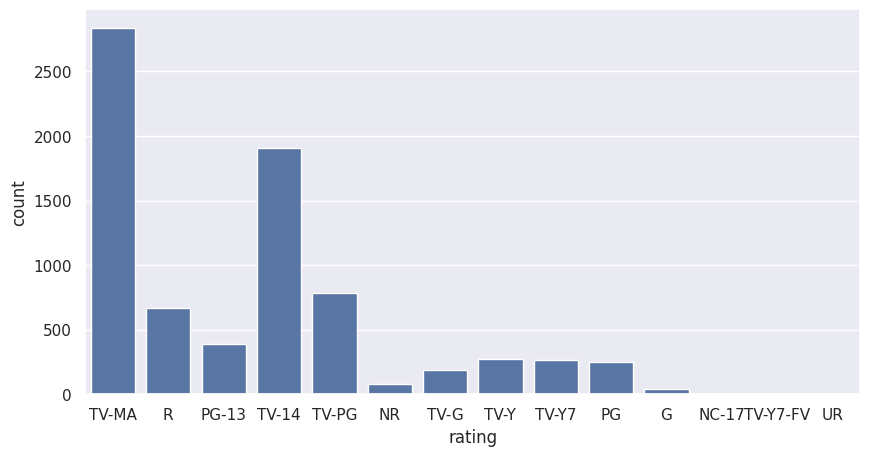

In [25]:
# Age ratings for shows in the dataset
plt.figure(figsize=(10,5))
sns.countplot(x='rating',data=df)

넷플릭스에서 가장 많은 프로그램은 TV-MA 등급을 받았으며,
그다음으로 많은 것은 TV-14 등급,
그 뒤를 이어 TV-PG 등급이다.


- TV-MA: 성인용 (Mature Audience) — 17세 이상 시청 권장
- TV-14: 14세 이상 시청 권장
- TV-PG: 보호자 시청 권장

In [26]:
# Age ratings
df.rating.unique()

array(['TV-MA', 'R', 'PG-13', 'TV-14', 'TV-PG', 'NR', 'TV-G', 'TV-Y', nan,
       'TV-Y7', 'PG', 'G', 'NC-17', 'TV-Y7-FV', 'UR'], dtype=object)

In [27]:
# Changing the values in the rating column
rating_map = {'TV-MA':'Adults',
              'R':'Adults',
              'PG-13':'Teens',
              'TV-14':'Young Adults',
              'TV-PG':'Older Kids',
              'NR':'Adults',
              'TV-G':'Kids',
              'TV-Y':'Kids',
              'TV-Y7':'Older Kids',
              'PG':'Older Kids',
              'G':'Kids',
              'NC-17':'Adults',
              'TV-Y7-FV':'Older Kids',
              'UR':'Adults'}

df['rating'].replace(rating_map, inplace = True)
df['rating'].unique()

array(['Adults', 'Teens', 'Young Adults', 'Older Kids', 'Kids', nan],
      dtype=object)

<Axes: xlabel='rating', ylabel='count'>

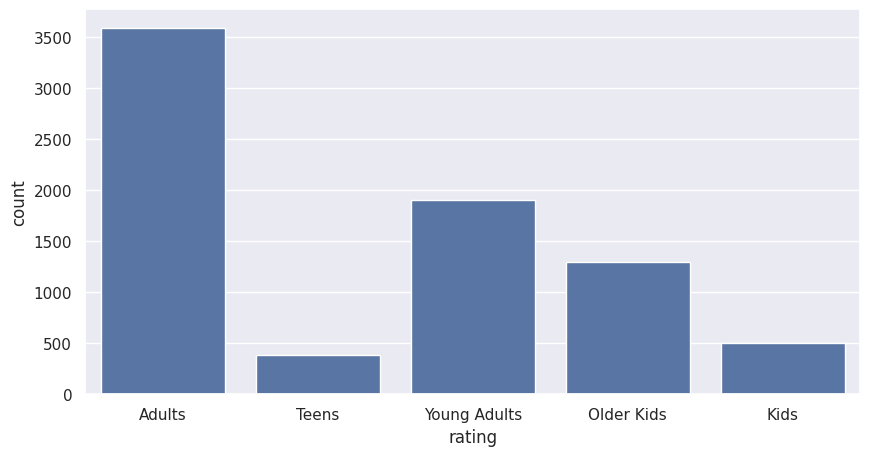

In [28]:
# Age ratings for shows in the dataset
plt.figure(figsize=(10,5))
sns.countplot(x='rating',data=df)

### 🧠 결론
> 넷플릭스는 **성인 및 청년층 중심의 콘텐츠 구성**을 가지고 있으며,  
> **어린이·청소년용 콘텐츠 비중은 상대적으로 낮다.**

# **5. Exploratory Data Analysis:**

## **5.1. Univatiate Analysis:**

Text(0.5, 1.0, 'Movies and TV Shows in the dataset')

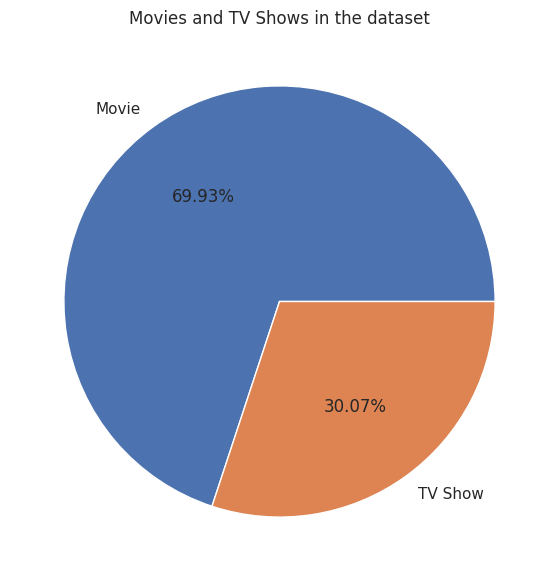

In [29]:
# Number of Movies and TV Shows in the dataset
plt.figure(figsize=(7,7))
df.type.value_counts().plot(kind='pie',autopct='%1.2f%%')
plt.ylabel('')
plt.title('Movies and TV Shows in the dataset')

* **There are more movies (69.14%) than TV shows (30.86%)  in the dataset.**

Text(0.5, 1.0, 'Top 10 directors by number of shows directed')

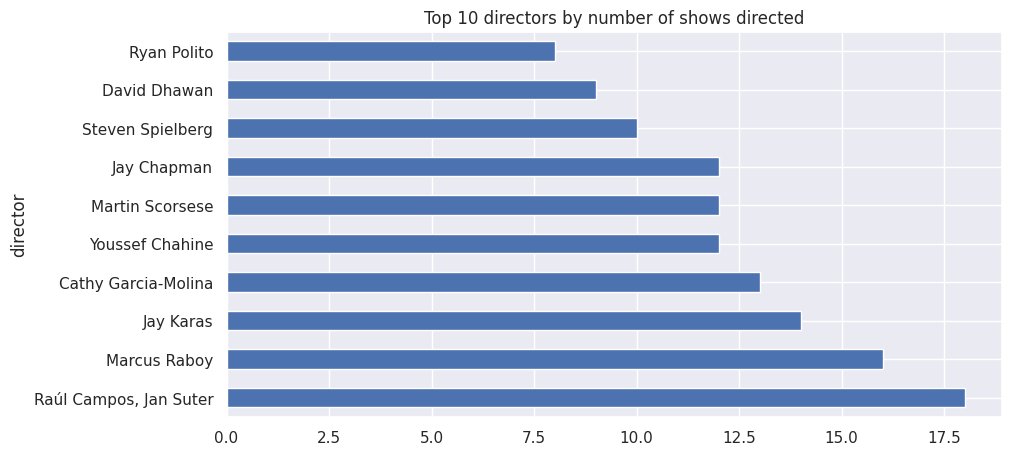

In [30]:
# Top 10 directors in the dataset
plt.figure(figsize=(10,5))
df[~(df['director']=='Unknown')].director.value_counts().nlargest(10).plot(kind='barh')
plt.title('Top 10 directors by number of shows directed')

* **Raul Campos와 Jan Suter는 함께 총 18편의 영화/TV 프로그램을 감독했으며, 이는 데이터셋 내에서 가장 높은 수치**

Text(0.5, 1.0, ' Top 10 countries with the highest number of shows')

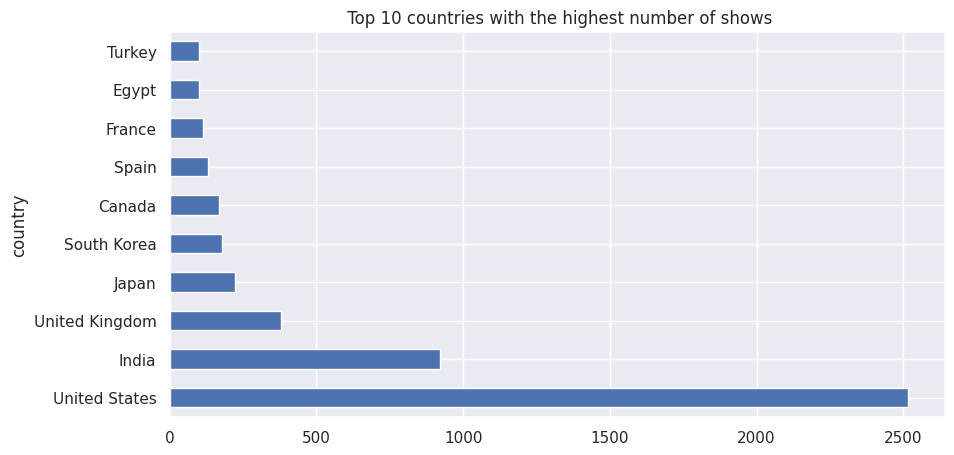

In [31]:
# Top 10 countries with the highest number movies / TV shows in the dataset
plt.figure(figsize=(10,5))
df[~(df['country']=='Unknown')].country.value_counts().nlargest(10).plot(kind='barh')
plt.title(' Top 10 countries with the highest number of shows')

* **가장 많은 영화/TV 프로그램은 미국에서 제작되었고, 그 다음으로 인도와 영국이 뒤를 이었다.**

In [32]:
# % share of movies / tv shows by top 3 countries
df.country.value_counts().nlargest(3).sum()/len(df)*100

np.float64(49.65535180127455)

In [33]:
# % share of movies / tv shows by top 10 countries
df.country.value_counts().nlargest(10).sum()/len(df)*100

np.float64(62.84302249967486)

* **상위 3개 국가는 전체 영화와 TV 프로그램의 약 56%를 차지한다.
이 수치는 상위 10개 국가를 기준으로 하면 약 78%까지 증가한다.**

Text(0.5, 1.0, 'distribution by released year')

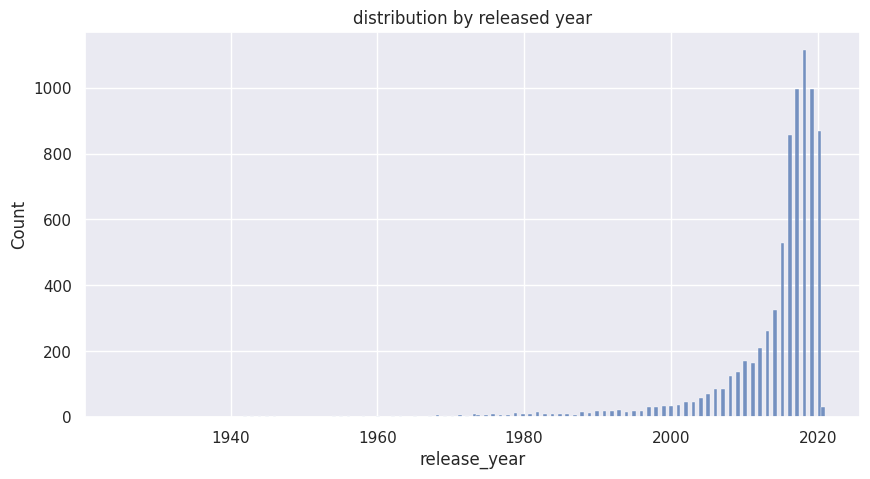

In [34]:
# Visualizing the year in which the movie / tv show was released
plt.figure(figsize=(10,5))
sns.histplot(df['release_year'])
plt.title('distribution by released year')

* **Netflix has greater number of new movies / TV shows than the old ones.**

Text(0.5, 1.0, 'Top 10 genres')

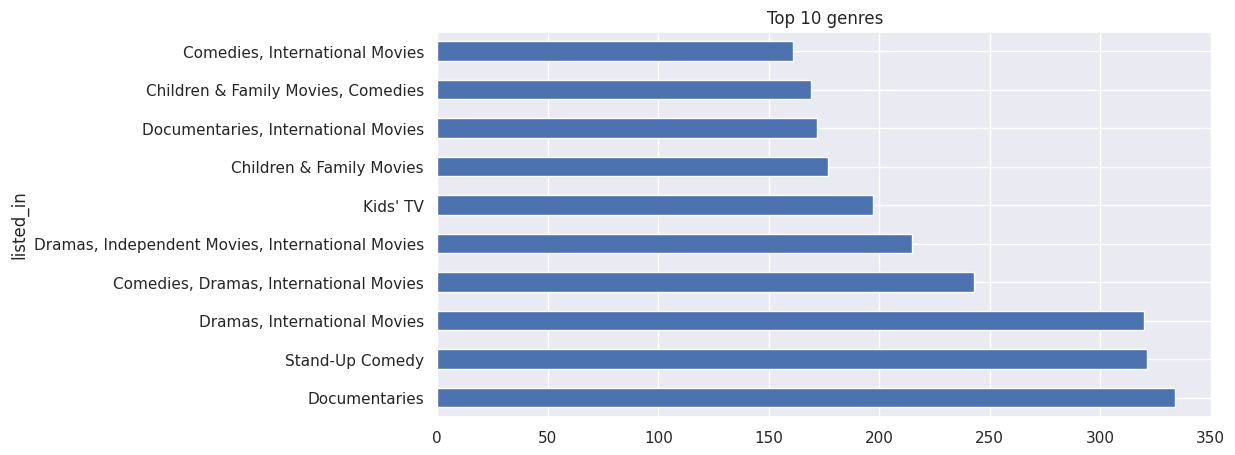

In [35]:
# Top 10 genres
plt.figure(figsize=(10,5))
df.listed_in.value_counts().nlargest(10).plot(kind='barh')
plt.title('Top 10 genres')

In [42]:
# Share of top 3 genres
df.listed_in.value_counts().nlargest(3).sum()/len(df)*100

np.float64(12.680452594615685)

In [43]:
# Share of top 10 genres
df.listed_in.value_counts().nlargest(10).sum()/len(df)*100

np.float64(30.02991286253089)

아니 왜 값이 다름???

- 가장 인기 있는 장르는 드라마이며, 그 뒤를 코미디와 다큐멘터리가 잇는다.
- 이 세 장르는 전체 영화 및 TV 프로그램의 약 41%를 차지하며,
상위 10개 장르를 포함하면 약 82%까지 비중이 높아진다.

Text(0.5, 0, '')

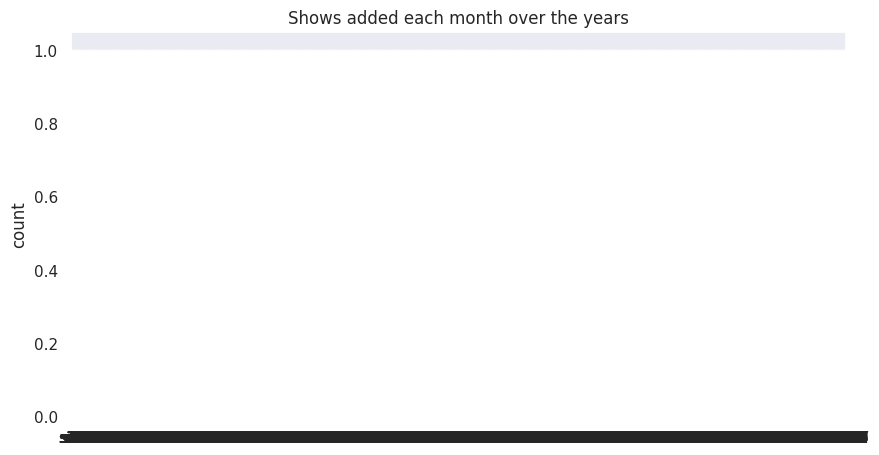

In [44]:
# Number of shows added on different months
plt.figure(figsize = (10,5))
sns.countplot(df['month_added'])
plt.title('Shows added each month over the years')
plt.xlabel('')

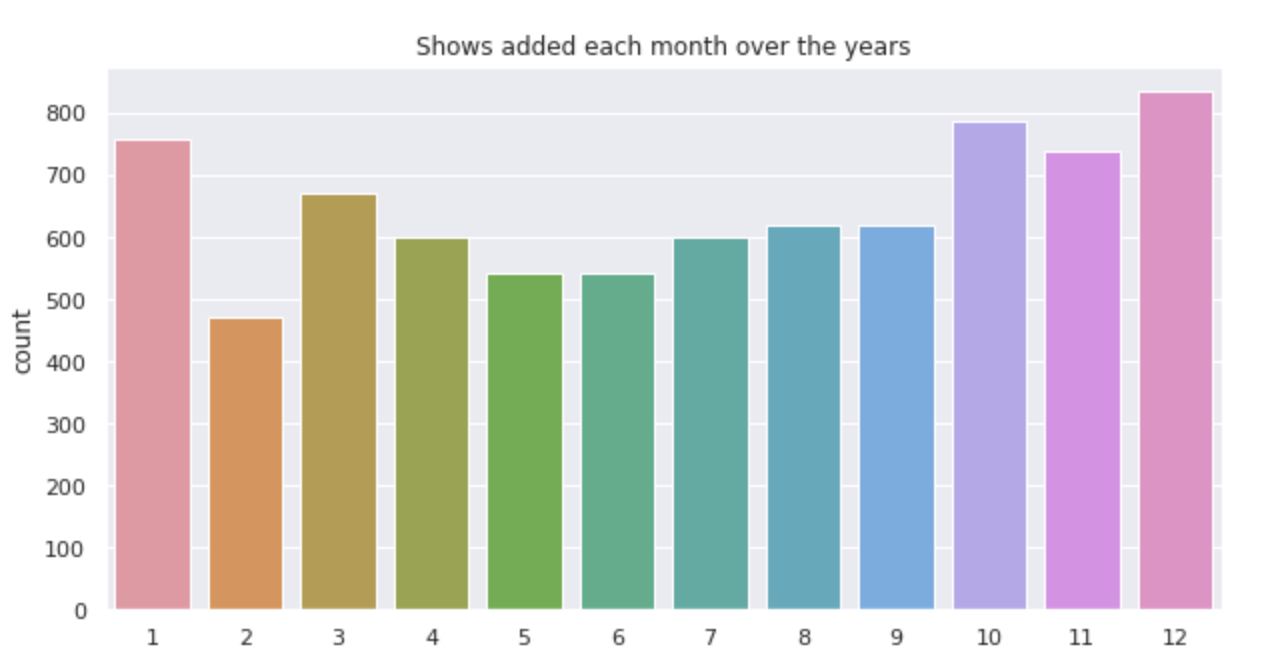

* **Over the years a greater number of shows were added in the months of October, November, December, and January.**

In [45]:
# Number of shows added over the years
plt.figure(figsize = (10,5))
sns.countplot(df['year_added'])
plt.title('Number of shows added each year')
plt.xlabel('')

Text(0.5, 0, '')

Error in callback <function flush_figures at 0x7e953fbc99e0> (for post_execute):


KeyboardInterrupt: 

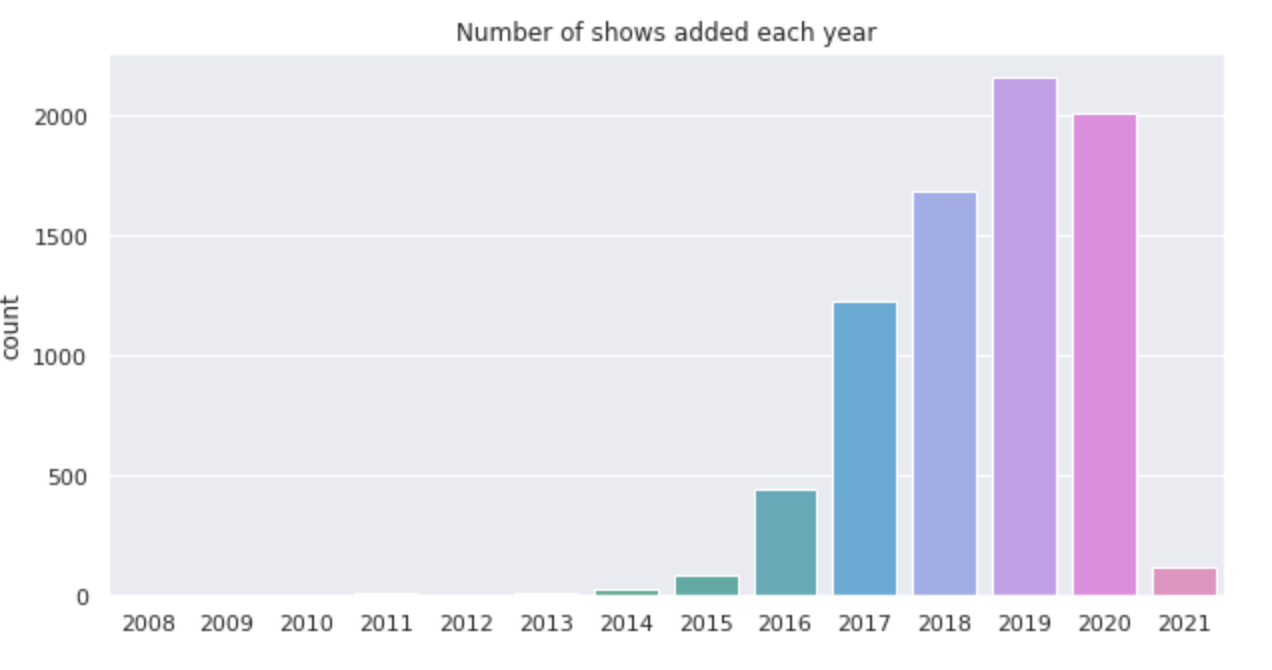

코드 실행하면 시각화가 이상하게 나옴,,

- 넷플릭스는 여러 해에 걸쳐 플랫폼에 더 많은 콘텐츠를 지속적으로 추가해 왔다.
- 2020년에 추가된 콘텐츠 수가 감소했는데, 이는 코로나19로 인한 봉쇄 조치로 인해 제작이 중단된 영향으로 보인다.
- 넷플릭스 데이터는 2021년 1월 16일까지의 정보만 포함되어 있기 때문에, 해당 연도에는 추가된 영화 수가 적게 나타난다.

Text(0.5, 1.0, 'Number of shows on Netflix for different age groups')

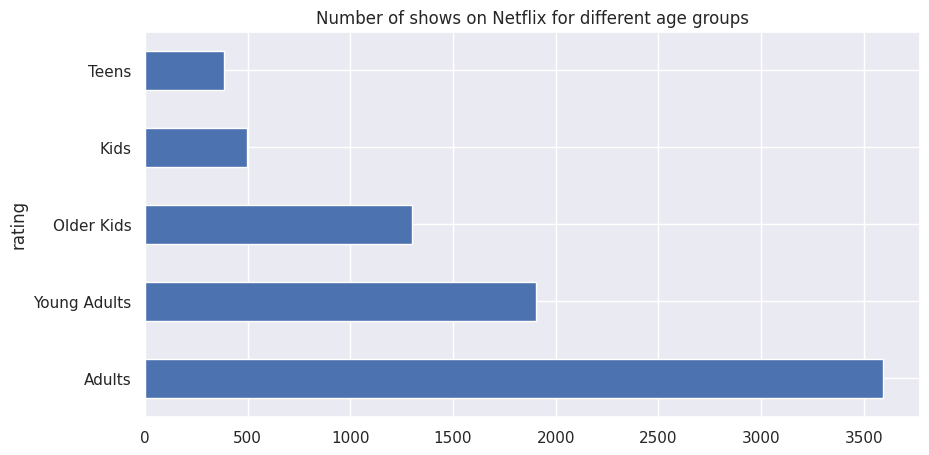

In [ ]:
# Number of shows on Netflix for different age groups
plt.figure(figsize=(10,5))
df.rating.value_counts().plot(kind='barh')
plt.title('Number of shows on Netflix for different age groups')

* **넷플릭스의 대부분의 프로그램은 성인 및 청년층의 취향과 필요에 맞춰 제작되어 있다.**

## **5.2. Bivariate analysis:**


이 분석에서는 **이변량 분석(Bivariate Analysis)** 을 통해  
`연도(year)`와 `콘텐츠 유형(type: Movie / TV Show)` 간의 관계를 살펴본다.

- `countplot()`을 사용하여 **연도별 추가된 콘텐츠 수(`year_added`)**와  
  **실제 제작된 콘텐츠의 연도(`release_year`)**를 각각 시각화했다.
- 두 변수 간의 상관적 변화를 통해  
  **넷플릭스의 콘텐츠 업로드·제작 트렌드 변화**를 파악하는 것이 목적이다.
- 이를 통해 **플랫폼 성장 추세, TV 시리즈 비중 증가, 코로나 영향(2020)** 등의  
  시계열적 패턴을 해석할 수 있다.

📊 **핵심 포인트:**  
> 단일 변수의 빈도 분석을 넘어,  
> ‘시간’과 ‘콘텐츠 유형’이라는 두 변수를 함께 비교함으로써  
> 넷플릭스의 콘텐츠 전략 변화를 입체적으로 이해하는 분석이다.


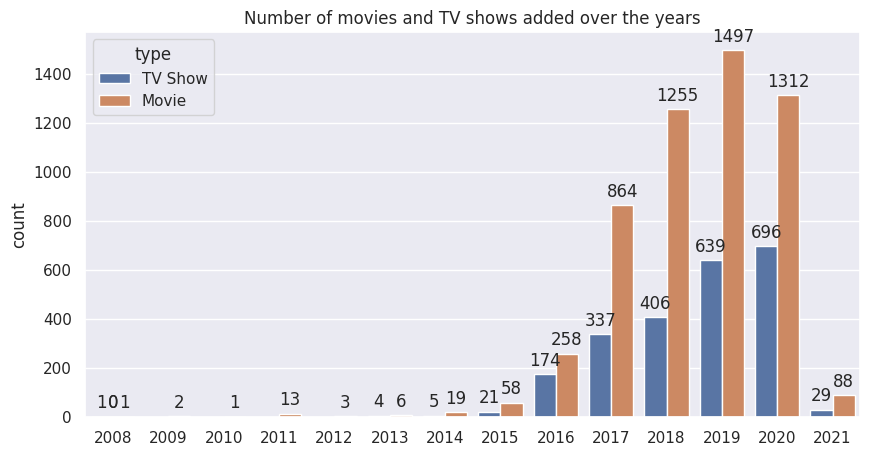

In [ ]:
# Number of movies and TV shows added over the years
plt.figure(figsize=(10,5))
p = sns.countplot(x='year_added',data=df, hue='type')
plt.title('Number of movies and TV shows added over the years')
plt.xlabel('')
for i in p.patches:
  p.annotate(format(i.get_height(), '.0f'), (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')

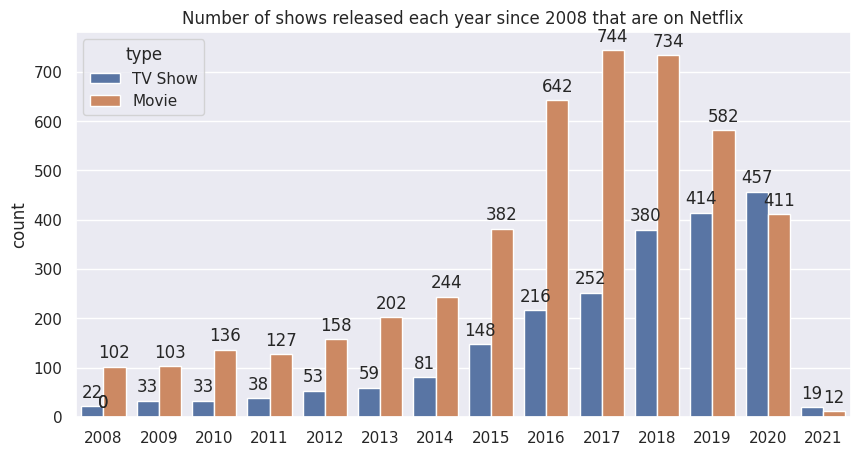

In [ ]:
# Number of shows released each year since 2008
order = range(2008,2022)
plt.figure(figsize=(10,5))
p = sns.countplot(x='release_year',data=df, hue='type',
                  order = order)
plt.title('Number of shows released each year since 2008 that are on Netflix')
plt.xlabel('')
for i in p.patches:
  p.annotate(format(i.get_height(), '.0f'), (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')

- 지난 몇 년 동안 넷플릭스는 자사 플랫폼에 더 많은 프로그램(쇼)을 추가하는 데 꾸준히 집중해왔다.

- 2020년에 추가된 영화의 수는 감소했지만, 같은 해에 추가된 TV 프로그램의 수에서는 이러한 감소 현상이 나타나지 않았다.

- 이는 넷플릭스가 영화보다는 TV 시리즈를 플랫폼에 더 많이 도입하는 방향으로 점점 집중하고 있음을 시사한다.

### 넷플릭스의 경우 자체 시리즈 콘텐츠를 많이 제작함. 특정 날짜에 전체 시리즈를 배포하니, released_year이랑 date_added가 같은 것 중에 넷플릭스 자체 콘텐츠가 많지 않을까...


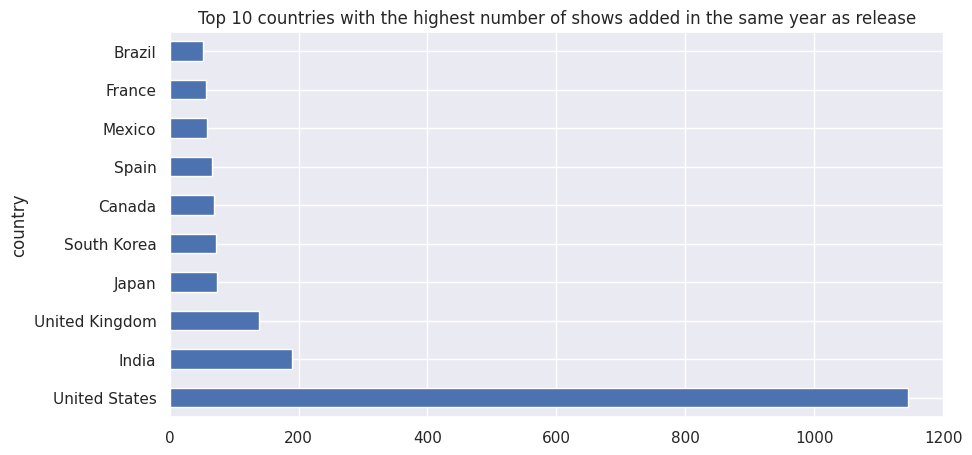

In [49]:
# Top 10 countries with the highest number of movies / TV shows added in the same year as release
plt.figure(figsize=(10,5))
same_year_df[~(same_year_df['country']=='Unknown')].country.value_counts().nlargest(10).plot(kind='barh')
plt.title('Top 10 countries with the highest number of shows added in the same year as release')
plt.show()

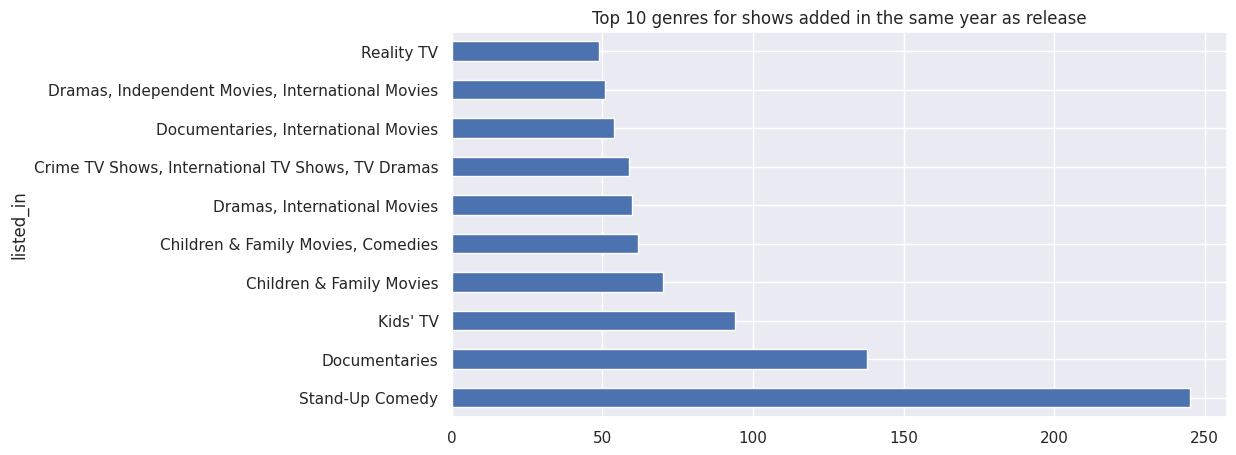

In [50]:
# Top 10 genres for shows added in the same year as release
plt.figure(figsize=(10,5))
same_year_df.listed_in.value_counts().nlargest(10).plot(kind='barh')
plt.title('Top 10 genres for shows added in the same year as release')
plt.show()

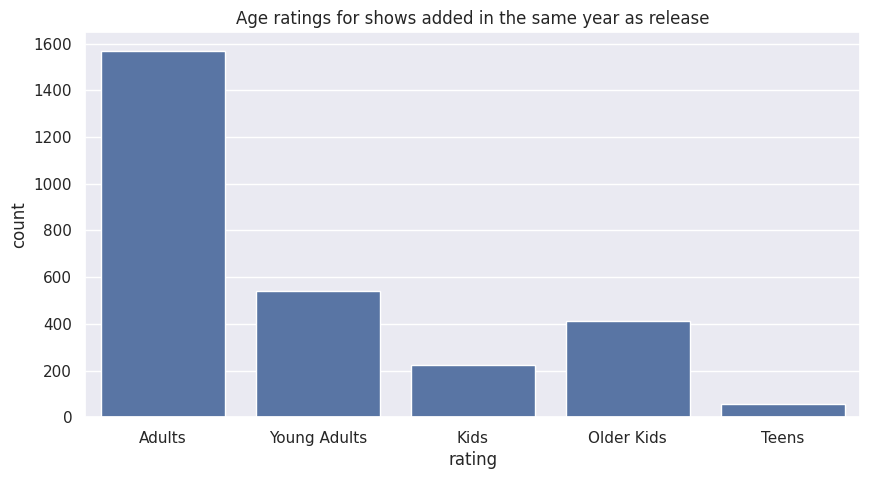

In [51]:
# Age ratings for shows added in the same year as release
plt.figure(figsize=(10,5))
sns.countplot(x='rating',data=same_year_df)
plt.title('Age ratings for shows added in the same year as release')
plt.show()

In [46]:
# Filter for shows where the year added is the same as the release year
same_year_df = df[df['year_added'] == df['release_year']].copy()

# Display the head of the filtered DataFrame
print("DataFrame filtered for shows added in the same year as their release year:")
display(same_year_df.head())

DataFrame filtered for shows added in the same year as their release year:


,type,title,director,cast,country,release_year,rating,duration,listed_in,description,month_added,year_added
show_id,,,,,,,,,,,,
s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020,Adults,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,8,2020
s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016,Adults,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,12,2016
s9,Movie,706,Shravan Kumar,"Divya Dutta, Atul Kulkarni, Mohan Agashe, Anup...",India,2019,Young Adults,118 min,"Horror Movies, International Movies","When a doctor goes missing, his psychiatrist w...",4,2019
s11,Movie,1922,Zak Hilditch,"Thomas Jane, Molly Parker, Dylan Schmid, Kaitl...",United States,2017,Adults,103 min,"Dramas, Thrillers",A farmer pens a confession admitting to his wi...,10,2017
s12,TV Show,1983,NaN,"Robert Więckiewicz, Maciej Musiał, Michalina O...","Poland, United States",2018,Adults,1 Season,"Crime TV Shows, International TV Shows, TV Dramas","In this dark alt-history thriller, a naïve law...",11,2018


In [47]:
# Check the shape of the filtered DataFrame
print("\nShape of the filtered DataFrame:")
print(same_year_df.shape)


Shape of the filtered DataFrame:
(2806, 12)


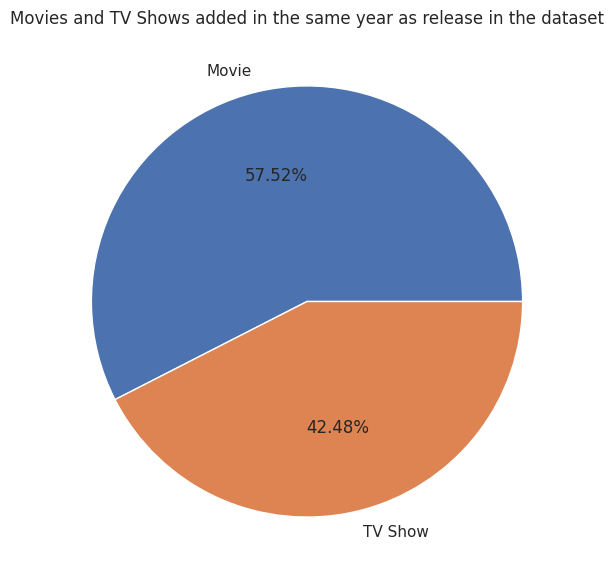

In [48]:
# Number of Movies and TV Shows in the filtered dataset
plt.figure(figsize=(7,7))
same_year_df.type.value_counts().plot(kind='pie',autopct='%1.2f%%')
plt.ylabel('')
plt.title('Movies and TV Shows added in the same year as release in the dataset')
plt.show()

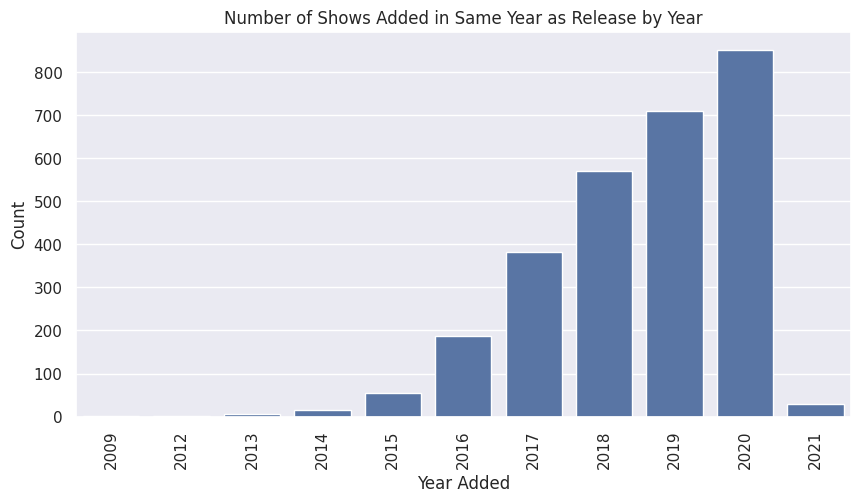

In [53]:
# Number of shows added in the same year as release, plotted by year
plt.figure(figsize=(10,5))
sns.countplot(x='year_added', data=same_year_df)
plt.title('Number of Shows Added in Same Year as Release by Year')
plt.xlabel('Year Added')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

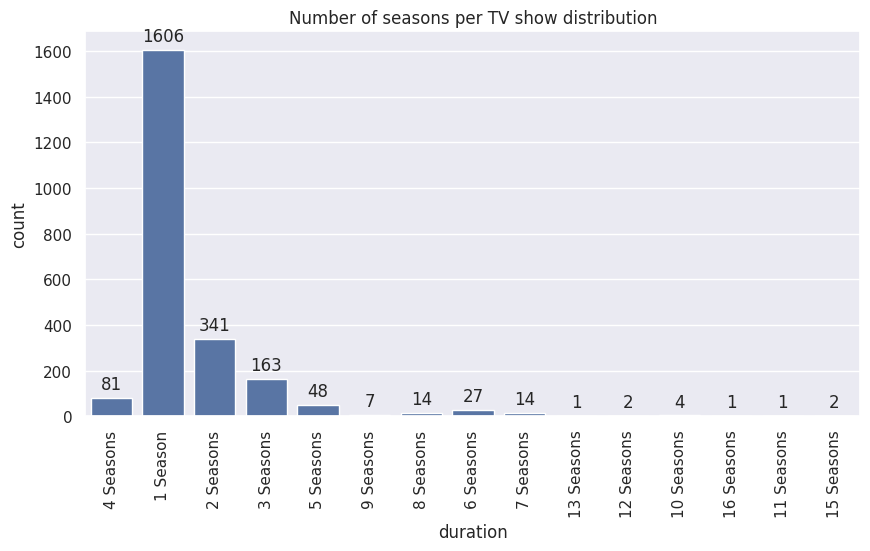

In [52]:
# Seasons in each TV show
plt.figure(figsize=(10,5))
p = sns.countplot(x='duration',data=df[df['type']=='TV Show'])
plt.title('Number of seasons per TV show distribution')
plt.xticks(rotation=90) # Rotate x-axis labels for readability

for i in p.patches:
  p.annotate(format(i.get_height(), '.0f'), (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')

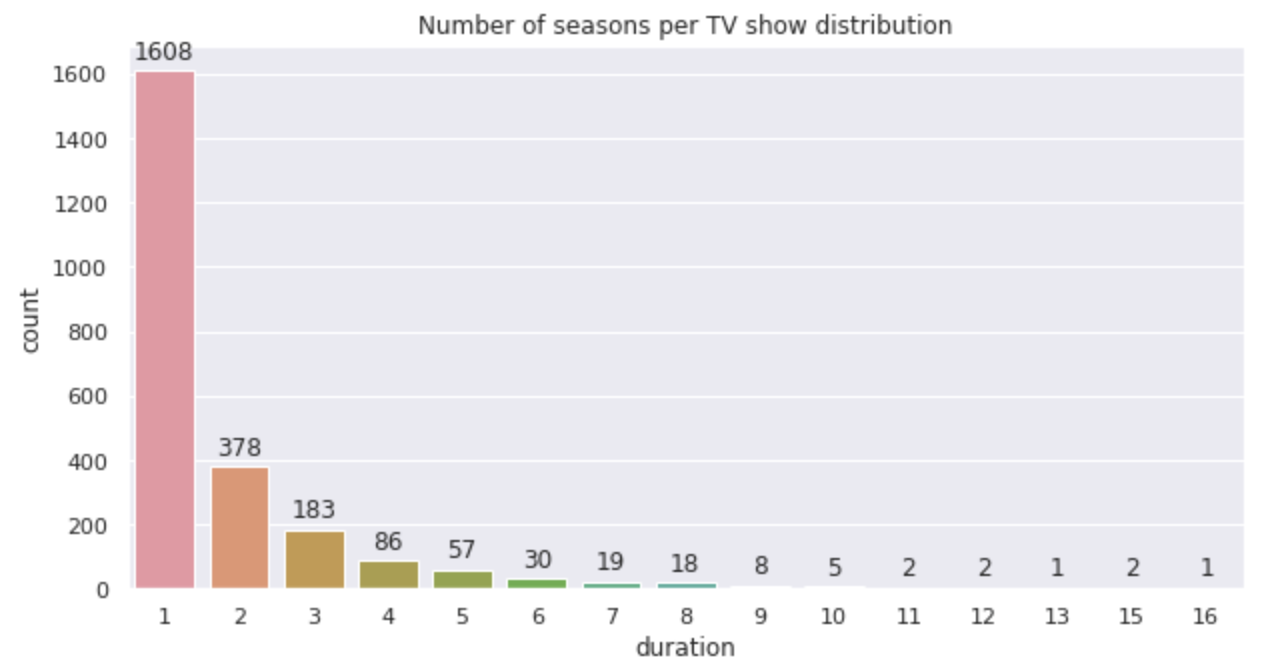

- 데이터셋에 포함된 TV 시리즈는 최대 16시즌까지 존재하지만, 대부분은 단 1시즌만 가지고 있다.

→ 이는 대부분의 TV 프로그램이 최근에 시작된 작품이며, 앞으로 더 많은 시즌이 제작될 가능성이 있음을 의미할 수 있다.

- 8시즌을 초과하는 TV 시리즈는 매우 적다.

→ 즉, 장기 방영되는 시리즈는 드물고, 대부분은 짧은 시즌 구조를 가지고 있다는 뜻이다.

released_year이랑 date_added가 같은 것들이 시리즈물이라면, 시리즈물은 거의 대부분 2019~2020 사이에 많이 나왔기 때문에, 2021년까지의 데이터를 포함하는 이 데이터셋 특성상 장기 방영되는 시리즈는 드물다라는 결론을 내리기는 힘들 것 같음

In [ ]:
# % of tv shows with just 1 season
len(df[(df['type']=='TV Show') & (df['duration']==1)]) / len(df[df['type']=='TV Show'])* 100

0.0

Text(0.5, 1.0, 'Movie duration distribution')

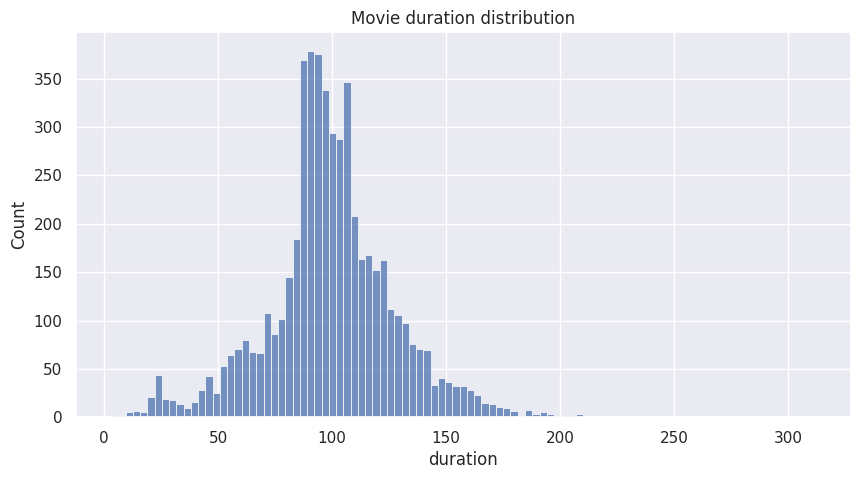

In [ ]:
# length of movie analysis
plt.figure(figsize=(10,5))
sns.histplot(x='duration',data=df[df['type']=='Movie'])
plt.title('Movie duration distribution')

In [ ]:
# Movie statistics
df[df['type']== 'Movie'].duration.describe()

,duration
count,5377.000000
mean,99.307978
std,28.530881
min,3.000000
25%,86.000000
50%,98.000000
75%,114.000000
max,312.000000


* **영화의 길이는 최소 3분에서 최대 312분까지 다양하며, 분포는 거의 정규분포 형태를 띈다.**

Text(0.5, 0, 'Year')

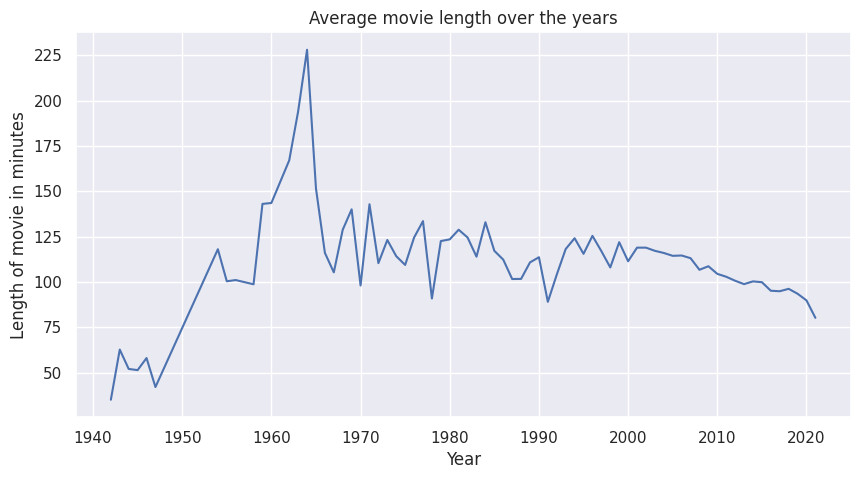

In [ ]:
# Average movie length over the years
plt.figure(figsize=(10,5))
df[df['type']=='Movie'].groupby('release_year')['duration'].mean().plot(kind='line')
plt.title('Average movie length over the years')
plt.ylabel('Length of movie in minutes')
plt.xlabel('Year')

In [ ]:
# Movie release year statistics
df[df['type']== 'Movie'].release_year.describe()

,release_year
count,5377.000000
mean,2012.920030
std,9.663282
min,1942.000000
25%,2012.000000
50%,2016.000000
75%,2018.000000
max,2021.000000


* **넷플릭스에는 1942년에 개봉된 영화까지 포함하여 매우 오래된 다양한 영화들이 있다.**
* **그래프에 따르면, 1940년대에 제작된 영화들은 평균적으로 상영 시간이 꽤 짧았다.**
* **평균적으로 1960년대에 제작된 영화들이 가장 긴 상영 시간을 가지고 있다.**
* **2000년대 이후로 영화의 평균 상영 시간은 지속적으로 감소하고 있다.**

Text(0.5, 1.0, 'Top 10 genres for movies')

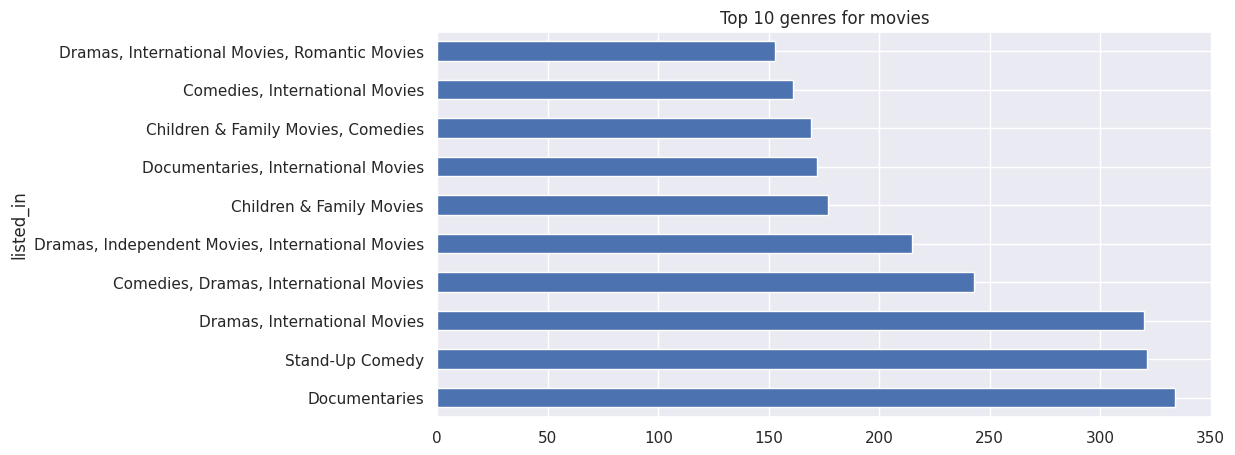

In [ ]:
# Top 10 genre for movies
plt.figure(figsize=(10,5))
df[df['type']=='Movie'].listed_in.value_counts().nlargest(10).plot(kind='barh')
plt.title('Top 10 genres for movies')

* **드라마, 코미디, 그리고 다큐멘터리가 넷플릭스 영화 중에서 가장 인기 있는 장르**

Text(0.5, 1.0, 'Top 10 genres for TV Shows')

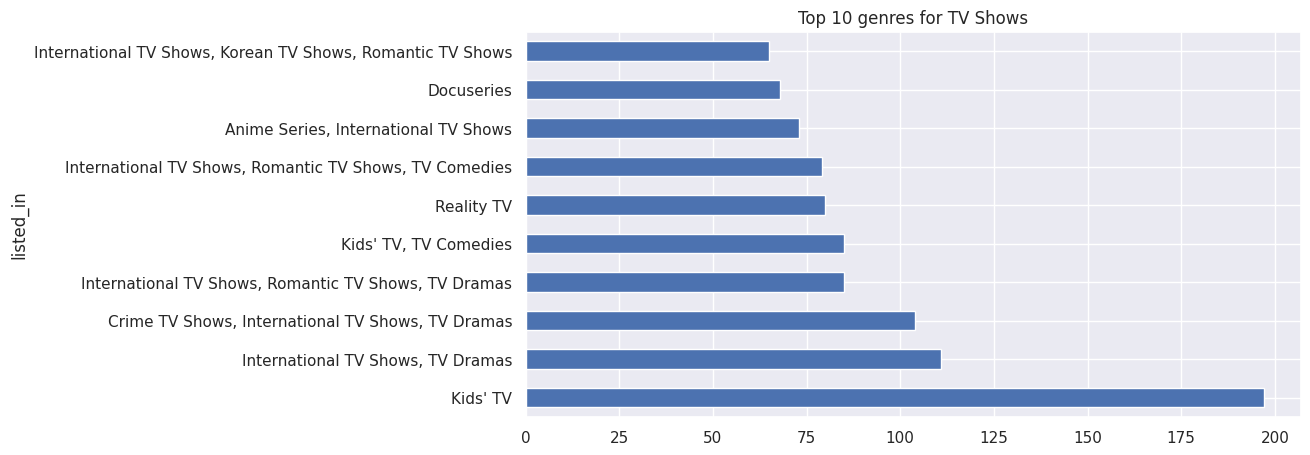

In [ ]:
# Top 10 genre for tv shows
plt.figure(figsize=(10,5))
df[df['type']=='TV Show'].listed_in.value_counts().nlargest(10).plot(kind='barh')
plt.title('Top 10 genres for TV Shows')

* **넷플릭스 TV 프로그램 중에서 가장 인기 있는 장르는 국제물(International), 범죄(crime), 아동(kids) 장르이다.**

Text(0.5, 1.0, 'Top 10 movie directors')

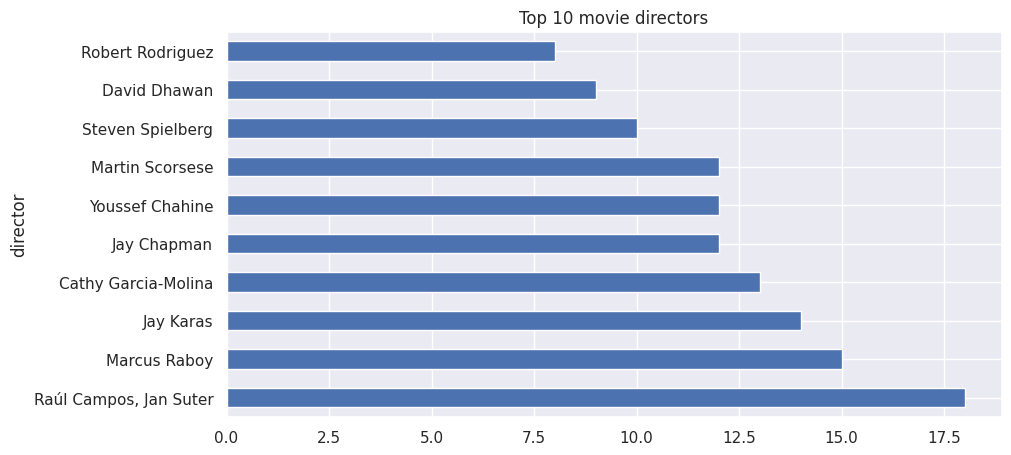

In [ ]:
# Top 10 movie directors
plt.figure(figsize=(10,5))
df[~(df['director']=='Unknown') & (df['type']=='Movie')].director.value_counts().nlargest(10).plot(kind='barh')
plt.title('Top 10 movie directors')

- Raul Campos와 Jan Suter는 총 18편의 영화를 공동 연출했으며, 이는 다른 어떤 감독보다도 많은 수치이다.

- 그 뒤를 Marcus Roboy, Jay Karas, Cathy Garcia-Molina가 잇는다.

Text(0.5, 1.0, 'Top 10 TV show directors')

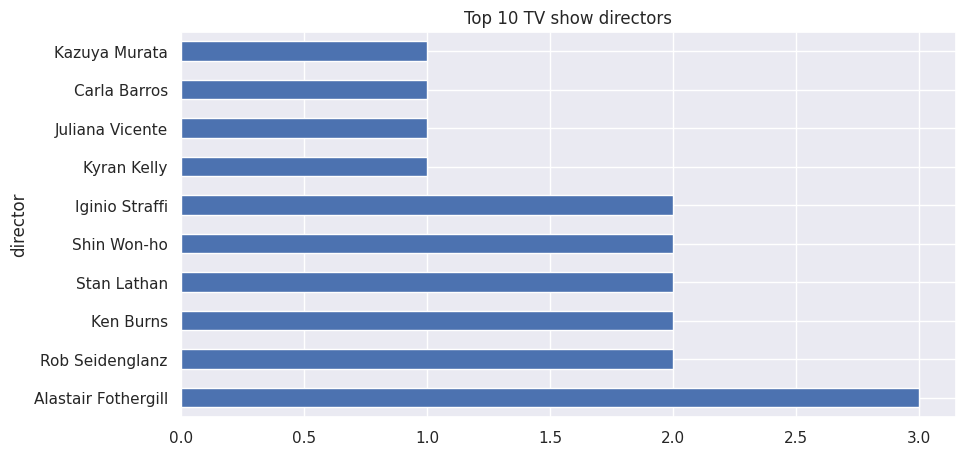

In [ ]:
# Top 10 TV show directors
plt.figure(figsize=(10,5))
df[~(df['director']=='Unknown') & (df['type']=='TV Show')].director.value_counts().nlargest(10).plot(kind='barh')
plt.title('Top 10 TV show directors')

- Alastair Fothergill은 3편의 TV 시리즈를 연출했으며, 이는 TV 프로그램 중 가장 많은 연출 수를 기록했다.

- 총 6명의 감독만이 2편 이상의 TV 프로그램을 연출한 것으로 나타났다.

Text(0.5, 1.0, 'Actors who have appeared in highest number of movies')

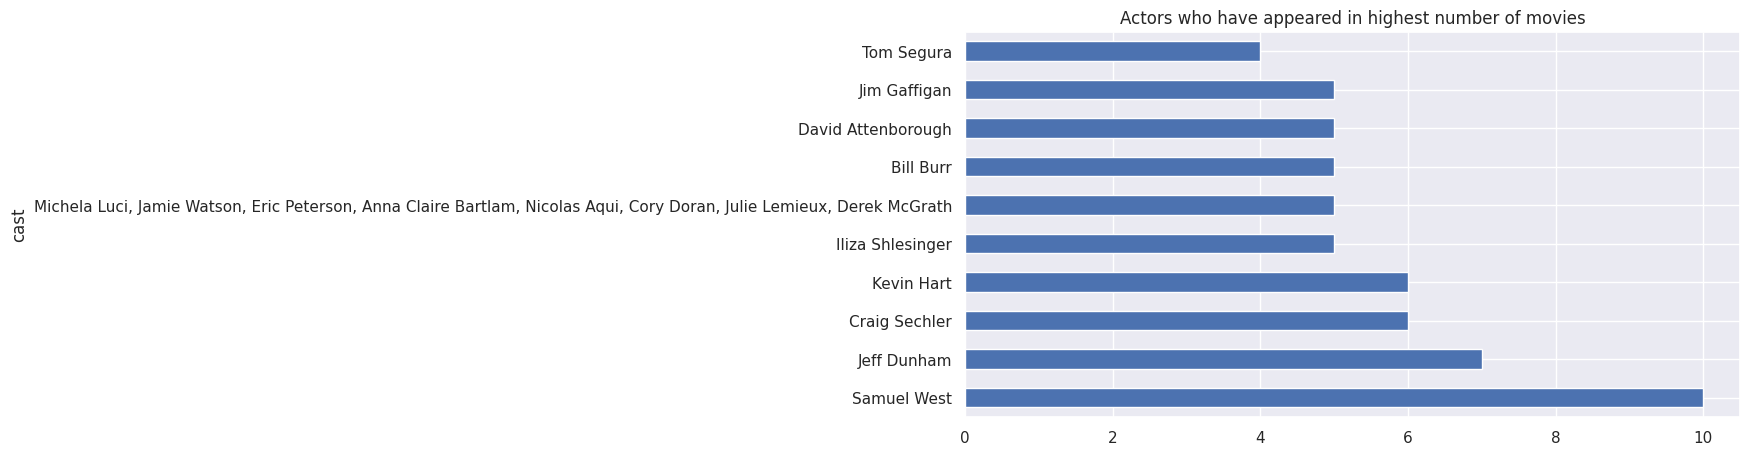

In [ ]:
# Top actors for movies
plt.figure(figsize=(10,5))
df[~(df['cast']=='Unknown') & (df['type']=='Movie')].cast.value_counts().nlargest(10).plot(kind='barh')
plt.title('Actors who have appeared in highest number of movies')

* 배우 Samuel West는 총 10편의 영화에 출연해 가장 많은 출연작을 보유하고 있으며, 그 다음은 7편의 영화에 출연한 Jeff Dunham이다.

Text(0.5, 1.0, 'Actors who have appeared in highest number of TV shows')

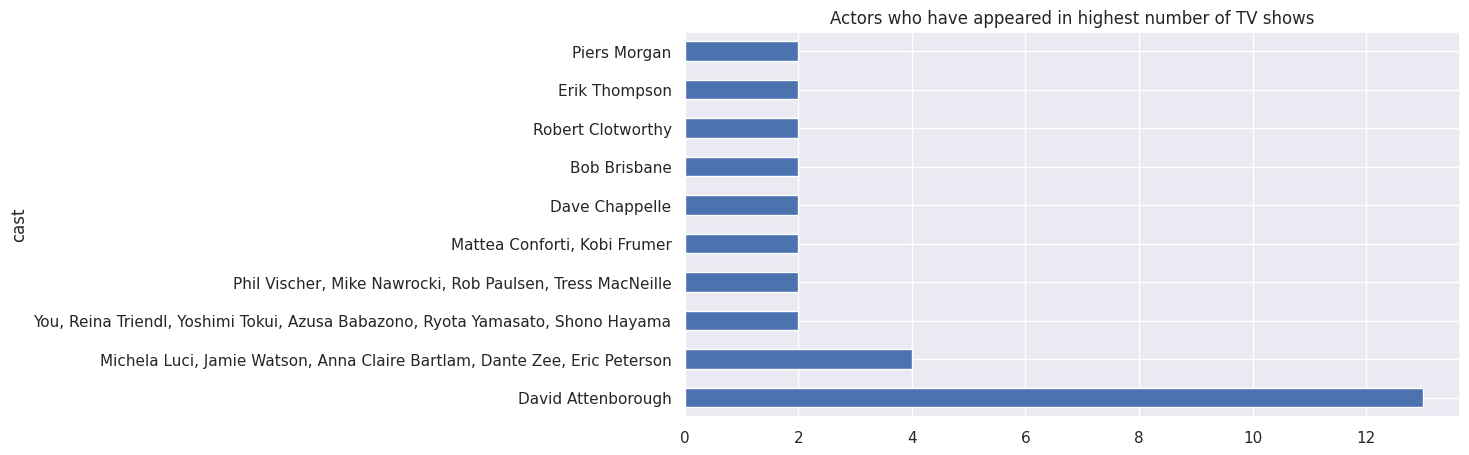

In [ ]:
# Top actors for TV shows
plt.figure(figsize=(10,5))
df[~(df['cast']=='Unknown') & (df['type']=='TV Show')].cast.value_counts().nlargest(10).plot(kind='barh')
plt.title('Actors who have appeared in highest number of TV shows')

* **David Attenborough는 13편의 TV 프로그램에 출연해 가장 많은 출연을 기록했으며, 그 뒤를 Michela Luci, Jamie Watson, Anna Claire Bartlam, Dante Zee, Eric Peterson이 4편으로 잇는다**

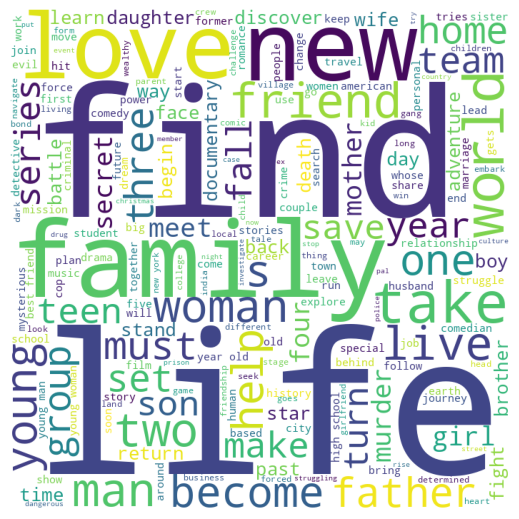

In [ ]:
# Building a wordcloud for the movie descriptions
comment_words = ''
stopwords = set(STOPWORDS)

# iterate through the csv file
for val in df.description.values:

    # typecaste each val to string
    val = str(val)

    # split the value
    tokens = val.split()

    # Converts each token into lowercase
    for i in range(len(tokens)):
        tokens[i] = tokens[i].lower()

    comment_words += " ".join(tokens)+" "

wordcloud = WordCloud(width = 700, height = 700,
                background_color ='white',
                stopwords = stopwords,
                min_font_size = 10).generate(comment_words)


# plot the WordCloud image
plt.figure(figsize = (10,5), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

### 넷플릭스 프로그램 설명에서 자주 등장하는 주요 키워드:

life(삶), family(가족), new(새로운), love(사랑), young(젊은), world(세계), group(그룹), death(죽음), man(남성), woman(여성), murder(살인), son(아들), girl(소녀), documentary(다큐멘터리), secret(비밀)**

좋은 시각화인 것 같다..

# **6. Data preprocessing:**

### 6.1. 모델링 접근 방식

- **클러스터링 기준 속성 선택**:
어떤 기준으로 프로그램을 묶을지를 결정

- **텍스트 전처리**:
ASCII(영문) 이외의 문자 제거

- **불용어(stopwords)** 및 문장부호 제거:
모든 텍스트를 소문자로 변환

- **표제어 추출(Lemmatization)**:
단어의 원형을 찾아 의미 있는 형태로 정리

- **토큰화(Tokenization)**:
문장을 단어 단위로 쪼개어 단어(토큰)들의 집합을 만듬

- **단어 벡터화(Word Vectorization)**:
텍스트 데이터를 수치 벡터로 변환(예: TF-IDF 등)

- **차원 축소(Dimensionality Reduction)**:
벡터 데이터의 차원을 줄여 연산 효율성을 높임.

- **클러스터링 알고리즘 적용**:
여러 군집화 알고리즘을 적용하여 최적의 클러스터 개수를 찾음

- **시각화**:
최적의 클러스터를 구성한 후, 각 클러스터의 주요 단어를 워드클라우드로 시각화

## 개념 정리
### 불용어(Stopwords)

**정의:**
불용어는 문장에서 자주 등장하지만 의미 분석에 큰 도움이 되지 않는 단어들을 의미
예: the, is, in, and, of 등

**불용어를 제거하면
텍스트 내 의미 있는 단어의 비율이 높아지고,
모델 학습 속도와 정확도가 향상됨**

예시:
"This is a good movie"->good movie

### 단어 벡터화(Word Vectorization)

**정의:**
단어 벡터화는 텍스트 데이터를 숫자(벡터) 형태로 변환하는 과정입니다.
컴퓨터는 문자를 이해하지 못하므로, 각 단어를 수학적으로 계산 가능한 수치로 표현

**대표적 방법:TF-IDF (Term Frequency – Inverse Document Frequency)**

텍스트 내 단어의 중요도를 계산하는 방법으로,
특정 문서에서 자주 등장하지만 다른 문서에는 드문 단어에 높은 가중치를 부여

- TF (Term Frequency):
단어가 한 문서에서 등장한 빈도

- IDF (Inverse Document Frequency):
단어가 전체 문서에서 얼마나 드물게 등장하는지

TF-IDF점수=TF×IDF

예시:
| 단어      | TF | IDF     | TF-IDF 점수 |
| ------- | -- | ------- | --------- |
| love    | 높음 | 낮음 (흔함) | 낮음        |
| vampire | 중간 | 높음 (희귀) | 높음        |

**벡터화의 목적**

- 텍스트를 수학적으로 계산 가능한 형태로 바꿔
→ 문서 간 유사도 계산 및 군집화(Clustering) 에 활용 가능

예를 들어 TF-IDF로 표현하면

| 영화         | love | drama | netflix | crime |
| ---------- | ---- | ----- | ------- | ----- |
| 🎬 Movie A | 0.8  | 0.2   | 0.0     | 0.0   |
| 🎬 Movie B | 0.1  | 0.3   | 0.5     | 0.6   |


→ 숫자 기반으로 비슷한 주제의 영화끼리 묶거나 추천 시스템에 활용 가능

### 요약
- 불용어 제거: 의미 없는 단어를 없애서 텍스트를 정제하는 단계

- 단어 벡터화: 정제된 단어를 숫자로 표현해 모델이 이해할 수 있도록 만드는 단계

넷플릭스 프로그램을 군집화할 기준 속성은 다음과 같다:

- 감독 (Director)

- 출연진 (Cast)

- 제작 국가 (Country)

- 장르 (Listed in / genres)

- 설명 (Description)

이런 기준 속성을 정하는 기준이 궁금함

In [54]:
# Using the original dataset for clustering since
# it does not require handling missing values
df1 = original_df.copy()

In [55]:
df1.fillna('',inplace=True)

In [56]:
# Combining all the clustering attributes into a single column

df1['clustering_attributes'] = (df1['director'] + ' ' +
                                df1['cast'] +' ' +
                                df1['country'] +' ' +
                                df1['listed_in'] +' ' +
                                df1['description'])

In [57]:
df1['clustering_attributes'][40]

'Muharrem Gülmez Erdem Yener, Ayhan Taş, Emin Olcay, Muharrem Gülmez, Elif Nur Kerkük, Tarık Papuççuoğlu, Suzan Aksoy, Doğa Konakoğlu, Esin Eden, Deniz Özerman Turkey Comedies, International Movies The slacker owner of a public bath house rallies his community to save it when a big developer comes to town to close it down and open a new mall.'

### 코드 요약

- **목적:** 클러스터링(군집화)에 사용할 텍스트 데이터를 준비하기 위함
- **주요 단계:**
  1. `original_df`를 복사하여 `df1` 생성 (원본 보호)
  2. 결측값(`NaN`)을 빈 문자열로 채움
  3. `director`, `cast`, `country`, `listed_in`, `description` 컬럼을 하나로 결합하여  
     `clustering_attributes` 열 생성
  4. 특정 행의 결합 결과(`df1['clustering_attributes'][40]`)를 확인
- **결과:** 각 콘텐츠(영화/TV쇼)에 대한 모든 주요 텍스트 정보를 포함한  
  단일 문자열 컬럼이 생성되어, 이후 **TF-IDF 벡터화 및 군집화**에 활용됨


* **모든 필요한 데이터를 하나의 열(column)에 성공적으로 합침**

## **6.2. Removing non-ASCII characters:**

###비ASCII(Non-ASCII) 문자 제거

- **목적:**  
  데이터 내 문자열에서 영어(ASCII)가 아닌 문자(예: 한글, 이모지, 특수문자 등)를 제거하여  
  텍스트 정제 및 벡터화 과정에서 오류를 방지하기 위함


In [58]:
# function to remove non-ascii characters

def remove_non_ascii(words):
    """Function to remove non-ASCII characters"""
    new_words = []
    for word in words:
        new_word = unicodedata.normalize('NFKD', word).encode('ascii', 'ignore').decode('utf-8', 'ignore')
        new_words.append(new_word)
    return new_words

In [59]:
# remove non-ascii characters
df1['clustering_attributes'] = remove_non_ascii(df1['clustering_attributes'])

In [60]:
df1['clustering_attributes'][40]

'Muharrem Gulmez Erdem Yener, Ayhan Tas, Emin Olcay, Muharrem Gulmez, Elif Nur Kerkuk, Tark Papuccuoglu, Suzan Aksoy, Doga Konakoglu, Esin Eden, Deniz Ozerman Turkey Comedies, International Movies The slacker owner of a public bath house rallies his community to save it when a big developer comes to town to close it down and open a new mall.'

* **We have successfully removed all non-ascii characters from the corpus.**

## **6.3. Remove stopwords and lower case:**

In [61]:
# extracting the stopwords from nltk library
import nltk
from nltk.corpus import stopwords
sw = stopwords.words('english')
# displaying the stopwords
np.array(sw)

array(['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all',
       'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at',
       'be', 'because', 'been', 'before', 'being', 'below', 'between',
       'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did',
       'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don',
       "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further',
       'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven',
       "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers',
       'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd",
       'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it',
       "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll',
       'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn',
       "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not',
       'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'ot

nltk 라이브러리에 불용어 모음이 있음

In [62]:
# function to remove stop words
def stopwords(text):
    '''a function for removing the stopword'''
    # removing the stop words and lowercasing the selected words
    text = [word.lower() for word in text.split() if word.lower() not in sw]
    # joining the list of words with space separator
    return " ".join(text)

In [63]:
# Removing stop words
df1['clustering_attributes'] = df1['clustering_attributes'].apply(stopwords)

In [64]:
df1['clustering_attributes'][40]

'muharrem gulmez erdem yener, ayhan tas, emin olcay, muharrem gulmez, elif nur kerkuk, tark papuccuoglu, suzan aksoy, doga konakoglu, esin eden, deniz ozerman turkey comedies, international movies slacker owner public bath house rallies community save big developer comes town close open new mall.'

* **We have successfully removed all the stopwords and converted the corpus to lowercase.**

## **6.4. Remove punctuations**

## 구두점(Punctuation) 제거 단계

---

### **목적**
텍스트 데이터에서 `, . ! ? : ; () 등`과 같은 **구두점(문장부호)** 은  
의미 분석에는 도움이 되지 않으므로 제거하여  
**데이터의 일관성**과 **벡터화 정확도**를 높이기 위함


In [65]:
# function to remove punctuations
def remove_punctuation(text):
    '''a function for removing punctuation'''
    translator = str.maketrans('', '', string.punctuation)
    # return the text stripped of punctuation marks
    return text.translate(translator)

In [66]:
# Removing punctuation marks
df1['clustering_attributes'] = df1['clustering_attributes'].apply(remove_punctuation)

In [67]:
df1['clustering_attributes'][40]

'muharrem gulmez erdem yener ayhan tas emin olcay muharrem gulmez elif nur kerkuk tark papuccuoglu suzan aksoy doga konakoglu esin eden deniz ozerman turkey comedies international movies slacker owner public bath house rallies community save big developer comes town close open new mall'

* **We have successfully dropped all the punctuation marks from the corpus.**

## **6.5. Lemmatization:**

### 🧩 코드 요약 — Lemmatization(표제어 추출)

이 코드는 `clustering_attributes` 열에 포함된 단어들을 **표제어(Lemma)** 형태로 변환하는 과정을 수행한다.  
표제어란 단어의 기본형, 즉 사전에서 찾을 수 있는 원형을 의미하며,  
예를 들어 “running”, “ran”, “runs”는 모두 “run”이 표제어이다.  

함수 `lemmatize_verbs()`는 NLTK의 `WordNetLemmatizer`를 이용하여 각 단어를 **동사(pos='v') 기준으로 표제어화**하고,  
그 결과를 리스트 형태로 반환한다. 이후 이 결과를 `df1['clustering_attributes']`에 다시 저장하여  
데이터프레임 내 모든 단어가 동사 원형으로 정규화되도록 한다.  
마지막 줄의 `df1['clustering_attributes'][40]`은 변환된 결과 중 **40번째 행의 데이터**를 확인하기 위한 코드이다.


In [68]:
# function to lemmatize the corpus
def lemmatize_verbs(words):
    """Lemmatize verbs in list of tokenized words"""
    lemmatizer = WordNetLemmatizer()
    lemmas = []
    for word in words:
        lemma = lemmatizer.lemmatize(word, pos='v')
        lemmas.append(lemma)
    return lemmas

In [69]:
# Lemmatization
df1['clustering_attributes'] = lemmatize_verbs(df1['clustering_attributes'])

In [70]:
df1['clustering_attributes'][40]

'muharrem gulmez erdem yener ayhan tas emin olcay muharrem gulmez elif nur kerkuk tark papuccuoglu suzan aksoy doga konakoglu esin eden deniz ozerman turkey comedies international movies slacker owner public bath house rallies community save big developer comes town close open new mall'

* **We have lemmatized the corpus.**

## **6.6. Tokenization:**

In [71]:
tokenizer = TweetTokenizer()

In [72]:
df1['clustering_attributes'] = df1['clustering_attributes'].apply(lambda x: tokenizer.tokenize(x))

* **The corpus is converted to tokens.**

**전체 텍스트(corpus)가 단어 단위의 토큰들로 변환**

## **6.7. Vectorization:**

### 6.7. Vectorization — TF-IDF 벡터화 과정 요약

이 단계에서는 텍스트 데이터를 **TF-IDF(Vectorization)** 방식으로 수치화하여, 이후 **클러스터링(Clustering)** 에 사용할 수 있도록 변환한다.  
TF-IDF는 **Term Frequency–Inverse Document Frequency**의 약자로, 단어의 중요도를 수치로 표현하는 방법이다.

---

###  **TF-IDF 개념 정리**

| 개념 | 수식 | 의미 |
|------|------|------|
| **TF (Term Frequency)** | 𝑇𝐹 = (단어 t가 문서에 등장한 횟수) / (문서 내 전체 단어 수) | 특정 문서에서 단어가 얼마나 자주 등장하는지를 나타냄 |
| **IDF (Inverse Document Frequency)** | 𝐼𝐷𝐹(t) = logₑ(전체 문서 수 / 단어 t를 포함한 문서 수) | 여러 문서에 흔히 등장하는 단어의 가중치를 낮춤 |
| **TF-IDF** | 𝑇𝐹𝐼𝐷𝐹 = 𝑇𝐹 × 𝐼𝐷𝐹 | 각 단어의 상대적 중요도를 계산 |

결과적으로, **자주 등장하지만 모든 문서에 공통적으로 있는 단어는 중요도가 낮고**,  
**특정 문서에만 자주 등장하는 단어는 중요도가 높게 반영된다.**

---

### **코드 요약**

```python
# 텍스트 데이터 불러오기
clustering_data = df1['clustering_attributes']

# 토큰화 함수 (입력 그대로 반환)
def identity_tokenizer(text):
    return text

# TF-IDF 벡터화 수행
tfidf = TfidfVectorizer(
    tokenizer=identity_tokenizer,   # 사용자 정의 토크나이저
    stop_words='english',           # 영어 불용어 제거
    lowercase=False,                # 이미 전처리된 데이터이므로 소문자 변환 비활성화
    max_features=20000              # 시스템 과부하 방지를 위한 최대 피처 수 제한
)
X = tfidf.fit_transform(clustering_data)


* We can vectorize the corpus using TFIDF vectorizer, where TFIDF stands for - Term Frequency Inverse Document Frequency.

\begin{align}
        TF = \frac{Number\ of\ times\ term\ t\ appears\ in\ a\ document}{Total\ number\ of\ terms\ in\ the\ document}
    \end{align}

\begin{align}
        IDF(t) = log_e(\frac{Total\  number \ of \ documents}{ Number\ of\ documents\ with\ term\ t\ in\ it })
    \end{align}

\begin{align}
TFIDF = {TF\ *\ IDF}
    \end{align}

In [73]:
# clustering tokens saved in a variable
clustering_data = df1['clustering_attributes']

In [74]:
# Tokenization
def identity_tokenizer(text):
    return text

# Using TFIDF vectorizer to vectorize the corpus
# max features = 20000 to prevent system from crashing
tfidf = TfidfVectorizer(tokenizer=identity_tokenizer, stop_words='english', lowercase=False,max_features = 20000)
X = tfidf.fit_transform(clustering_data)

In [75]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 235079 stored elements and shape (7787, 20000)>

In [76]:
# Shape of X
X.shape

(7787, 20000)

In [77]:
# data type of vector
type(X)

scipy.sparse._csr.csr_matrix

In [78]:
# convert X into array form for clustering
X = X.toarray()

## **6.8. Dimensionality reduction using PCA:**

## **6.8. Dimensionality Reduction using PCA**

이 단계에서는 **PCA (Principal Component Analysis, 주성분 분석)** 기법을 사용하여  
TF-IDF로 변환된 고차원 데이터의 **차원을 축소(Dimensionality Reduction)** 한다.  

- PCA는 데이터의 분산을 가장 잘 설명하는 방향을 찾아  
원래 데이터의 **정보 손실을 최소화하면서 변수(피처) 수를 줄이는 방법**이다.

---

### **PCA 개념 정리**

| 개념 | 설명 |
|------|------|
| **주성분(Principal Component)** | 데이터의 분산이 가장 큰 방향을 나타내는 새로운 축 |
| **목적** | 고차원 데이터를 저차원으로 줄이면서 핵심 정보를 유지 |
| **효과** | 차원 축소로 인해 연산 속도 향상, 시각화 용이, 노이즈 제거 |
| **결과 해석** | 각 주성분이 전체 데이터의 분산(정보)을 얼마나 설명하는지 비율로 나타냄 (`explained_variance_ratio_`) |

---

### **코드 요약**

```python
# PCA 모델 생성 및 학습
pca = PCA(random_state=42)
pca.fit(X)

# 누적 분산 설명력 시각화
plt.figure(figsize=(10,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title('PCA - Cumulative explained variance vs number of components')
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')


* We can use PCA (Principal component Analysis) to reduce the dimensionality of data.

In [79]:
# using PCA to reduce dimensionality
pca = PCA(random_state=42)
pca.fit(X)

KeyboardInterrupt: 

In [ ]:
# Explained variance for different number of components
plt.figure(figsize=(10,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title('PCA - Cumulative explained variance vs number of components')
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')

- 약 7,500개의 주성분(components) 을 사용하면 데이터의 100% 분산(variance) 을 설명할 수 있다는 것을 확인했다.
- 또한, 상위 4,000개의 주성분만으로도 전체 분산의 80% 이상을 설명할 수 있다.
- 따라서 모델을 단순화하고 차원을 줄이기 위해, 상위 4,000개의 주성분만 선택해도 데이터의 핵심 정보(80% 이상 분산) 를 충분히 유지할 수 있다.

In [ ]:
# reducing the dimensions to 4000 using pca
pca = PCA(n_components=4000,random_state=42)
pca.fit(X)

In [ ]:
# transformed features
x_pca = pca.transform(X)

In [ ]:
# shape of transformed vectors
x_pca.shape

We have successfully reduced the dimensionality of data using PCA.

# **7. Clusters implementation:**

##  **7. Clusters Implementation**

### **7.1. K-Means Clustering**

이 단계에서는 **K-Means 클러스터링 알고리즘**을 사용하여 영화 및 TV 프로그램 데이터를 **유사한 특성끼리 그룹화(Cluster)** 한다.  
K-Means는 데이터를 `k`개의 군집으로 나누고, 각 군집의 중심점(centroid)과의 거리 차이를 최소화하도록 반복적으로 조정하는 비지도 학습 알고리즘이다.

---

### ⚙️ **1️⃣ Elbow Method (엘보우 기법) — 최적의 k 찾기**

```python
wcss = []
for i in range(1, 31):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=33)
    kmeans.fit(x_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1,31), wcss)
plt.title('The Elbow Method - KMeans clustering')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')


엘보우 메소드(Elbow Method) 는
K를 바꿔가며 WCSS 변화를 그래프로 그린 뒤,
감소 폭이 급격히 줄어드는 ‘꺾이는 지점’을 최적의 클러스터 수로 결정

## **7.1. K-Means Clustering:**

Building clusters using the K-means clustering algorithm.

Visualizing the elbow curve and Silhouette score to decide on the optimal number of clusters for K-means clustering algorithm.

In [ ]:
# Elbow method to find the optimal value of k
wcss=[]
for i in range(1,31):
  kmeans = KMeans(n_clusters=i,init='k-means++',random_state=33)
  kmeans.fit(x_pca)
  wcss_iter = kmeans.inertia_
  wcss.append(wcss_iter)

number_clusters = range(1,31)
plt.figure(figsize=(10,5))
plt.plot(number_clusters,wcss)
plt.title('The Elbow Method - KMeans clustering')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

NameError: name 'KMeans' is not defined

**클러스터 내의 각 점과 중심점(centroid) 사이의 거리 제곱합(WCSS, Within-Cluster Sum of Squares) 은
클러스터의 개수가 증가할수록 감소**

In [ ]:
# Plotting Silhouette score for different umber of clusters
range_n_clusters = range(2,31)
silhouette_avg = []
for num_clusters in range_n_clusters:
  # initialize kmeans
  kmeans = KMeans(n_clusters=num_clusters,init='k-means++',random_state=33)
  kmeans.fit(x_pca)
  cluster_labels = kmeans.labels_

  # silhouette score
  silhouette_avg.append(silhouette_score(x_pca, cluster_labels))

plt.figure(figsize=(10,5))
plt.plot(range_n_clusters,silhouette_avg)
plt.xlabel('Values of K')
plt.ylabel('Silhouette score')
plt.title('Silhouette analysis For Optimal k - KMeans clustering')
plt.show()

* **The highest Silhouette score is obtained for 6 clusters.**

Building 6 clusters using the k-means clustering algorithm:

In [ ]:
# Clustering the data into 19 clusters
kmeans = KMeans(n_clusters=6,init='k-means++',random_state=33)
kmeans.fit(x_pca)

In [ ]:
# Evaluation metrics - distortion, Silhouette score
kmeans_distortion = kmeans.inertia_
kmeans_silhouette_score = silhouette_score(x_pca, kmeans.labels_)

print((kmeans_distortion,kmeans_silhouette_score))

In [ ]:
# Adding a kmeans cluster number attribute
df1['kmeans_cluster'] = kmeans.labels_

In [ ]:
# Number of movies and tv shows in each cluster
plt.figure(figsize=(10,5))
q = sns.countplot(x='kmeans_cluster',data=df1, hue='type')
plt.title('Number of movies and TV shows in each cluster - Kmeans Clustering')
for i in q.patches:
  q.annotate(format(i.get_height(), '.0f'), (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')

**Successfully built 6 clusters using the k-means clustering algorithm.**

### **7.1.1. Building wordclouds for different clusters built:**

In [ ]:
# Building a wordcloud for the movie descriptions
def kmeans_worldcloud(cluster_num):
  comment_words = ''
  stopwords = set(STOPWORDS)

  # iterate through the csv file
  for val in df1[df1['kmeans_cluster']==cluster_num].description.values:

      # typecaste each val to string
      val = str(val)

      # split the value
      tokens = val.split()

      # Converts each token into lowercase
      for i in range(len(tokens)):
          tokens[i] = tokens[i].lower()

      comment_words += " ".join(tokens)+" "

  wordcloud = WordCloud(width = 700, height = 700,
                  background_color ='white',
                  stopwords = stopwords,
                  min_font_size = 10).generate(comment_words)


  # plot the WordCloud image
  plt.figure(figsize = (10,5), facecolor = None)
  plt.imshow(wordcloud)
  plt.axis("off")
  plt.tight_layout(pad = 0)

In [ ]:
# Wordcloud for cluster 0
kmeans_worldcloud(0)

**Keywords observed in cluster 0: life, new, family, friend, save, help, discover, home, teen**

In [ ]:
# Wordcloud for cluster 1
kmeans_worldcloud(1)

**Keywords observed in cluster 1: life, love, family, father, young, girl, man, woman, friend, daughter**

In [ ]:
# Wordcloud for cluster 2
kmeans_worldcloud(2)

**Keywords observed in cluster 2: young, world, girl, mysterious, humanity, life, student, school, battle, demon, force**

In [ ]:
# Wordcloud for cluster 3
kmeans_worldcloud(3)

**Keywords observed in cluster 3: love, life, family, romance, crime, murder, world, adventure**

In [ ]:
# Wordcloud for cluster 4
kmeans_worldcloud(4)

**Keywords observed in cluster 4: comedian, special, stand, comic, stage, sex, joke**

In [ ]:
# Wordcloud for cluster 5
kmeans_worldcloud(5)

**Keywords observed in cluster 5: documentary, world, life, filmmaker, american, life**

## **7.2. Hierarchical clustering:**

Building clusters using the agglomerative (hierarchical) clustering algorithm.

Visualizing the dendrogram to decide on the optimal number of clusters for the agglomerative (hierarchical) clustering algorithm:

In [ ]:
# Building a dendogram to decide on the number of clusters
plt.figure(figsize=(10, 7))
dend = shc.dendrogram(shc.linkage(x_pca, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Netflix Shows')
plt.ylabel('Distance')
plt.axhline(y= 3.8, color='r', linestyle='--')

**At a distance of 3.8 units, 12 clusters can be built using the agglomerative clustering algorithm.**

Building 12 clusters using the Agglomerative clustering algorithm:

In [ ]:
# Fitting hierarchical clustering model
hierarchical = AgglomerativeClustering(n_clusters=12, affinity='euclidean', linkage='ward')
hierarchical.fit_predict(x_pca)

In [ ]:
# Adding a kmeans cluster number attribute
df1['hierarchical_cluster'] = hierarchical.labels_

In [ ]:
# Number of movies and tv shows in each cluster
plt.figure(figsize=(10,5))
q = sns.countplot(x='hierarchical_cluster',data=df1, hue='type')
plt.title('Number of movies and tv shows in each cluster - Hierarchical Clustering')
for i in q.patches:
  q.annotate(format(i.get_height(), '.0f'), (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')

Successfully built 12 clusters using the Agglomerative (hierarchical) clustering algorithm.

### **7.2.1. Building wordclouds for different clusters built:**

In [ ]:
# Building a wordcloud for the movie descriptions
def hierarchical_worldcloud(cluster_num):
  comment_words = ''
  stopwords = set(STOPWORDS)

  # iterate through the csv file
  for val in df1[df1['hierarchical_cluster']==cluster_num].description.values:

      # typecaste each val to string
      val = str(val)

      # split the value
      tokens = val.split()

      # Converts each token into lowercase
      for i in range(len(tokens)):
          tokens[i] = tokens[i].lower()

      comment_words += " ".join(tokens)+" "

  wordcloud = WordCloud(width = 700, height = 700,
                  background_color ='white',
                  stopwords = stopwords,
                  min_font_size = 10).generate(comment_words)


  # plot the WordCloud image
  plt.figure(figsize = (10,5), facecolor = None)
  plt.imshow(wordcloud)
  plt.axis("off")
  plt.tight_layout(pad = 0)

In [ ]:
# Wordcloud for cluster 0
hierarchical_worldcloud(0)

**Keywords observed in cluster 0: life, new, find, family, save, friend, young, teen, adventure**

In [ ]:
# Wordcloud for cluster 1
hierarchical_worldcloud(1)

**Keywords observed in cluster 1: love, family, life, student, romance, school, woman, master, father**

In [ ]:
# Wordcloud for cluster 2
hierarchical_worldcloud(2)

**Keywords observed in cluster 2: life, new, series, crime, world, murder, history, detective**

In [ ]:
# Wordcloud for cluster 3
hierarchical_worldcloud(3)

**Keywords observed in cluster 3: family, life, love, friend, teen, woman, man, young, world, wedding, secret**

In [ ]:
# Wordcloud for cluster 4
hierarchical_worldcloud(4)

**Keywords observed in cluster 4: documentary, music, world, team, interview,history, family, career, battle, death**

In [ ]:
# Wordcloud for cluster 5
hierarchical_worldcloud(5)

**Keywords observed in cluster 5: family, life, mexico, young, new, woman, man, secret, spain, death, singer**

In [ ]:
# Wordcloud for cluster 6
hierarchical_worldcloud(6)

**Keywords observed in cluster 6: young, life, girl, world, friend, mysterious, demon, student, school, father**

In [ ]:
# Wordcloud for cluster 7
hierarchical_worldcloud(7)

**Keywords observed in cluster 7: love, life, woman, new, student, family, korea, secret, detective, young**

In [ ]:
# Wordcloud for cluster 8
hierarchical_worldcloud(8)

**Keywords observed in cluster 8: woman, man life, egypt, wealthy, money, young, love, revolution, struggling**

In [ ]:
# Wordcloud for cluster 9
hierarchical_worldcloud(9)

**Keywords observed in cluster 9: comedian, stand, life, comic, special, show, live, star, stage, hilarious, stories**

In [ ]:
# Wordcloud for cluster 10
hierarchical_worldcloud(10)

**Keywords observed in cluster 10: animal, nature, explore, planet, species, survive, natural, life, examine, earth**

In [ ]:
# Wordcloud for cluster 11
hierarchical_worldcloud(11)

**Keywords observed in cluster 11: love, man, woman, india, father, friend, girl, mumbai, city, learn, young**

# **8. Content based recommender system:**

* We can build a simple content based recommender system based on the similarity of the shows.
* If a person has watched a show on Netflix, the recommender system must be able to recommend a list of similar shows that s/he likes.
* To get the similarity score of the shows, we can use cosine similarity
* The similarity between two vectors (A and B) is calculated by taking the dot product of the two vectors and dividing it by the magnitude value as shown in the equation below. We can simply say that the CS score of two vectors increases as the angle between them decreases.

\begin{align}
        Cos(\theta) = \frac{A\ .\ B}{|A|\ .\ |B|}
    \end{align}

In [ ]:
# defining a new df for building a recommender system
recommender_df = df1.copy()

In [ ]:
# Changing the index of the df from show id to show title
recommender_df['show_id'] = recommender_df.index

In [ ]:
# converting tokens to string
def convert(lst):
  return ' '.join(lst)

recommender_df['clustering_attributes'] = recommender_df['clustering_attributes'].apply(lambda x: convert(x))

In [ ]:
# setting title of movies/Tv shows as index
recommender_df.set_index('title',inplace=True)

In [ ]:
# Count vectorizer
CV = CountVectorizer()
converted_matrix = CV.fit_transform(recommender_df['clustering_attributes'])

In [ ]:
# Cosine similarity
cosine_similarity = cosine_similarity(converted_matrix)

In [ ]:
cosine_similarity.shape

In [ ]:
# Developing a function to get 10 recommendations for a show
indices = pd.Series(recommender_df.index)

def recommend_10(title, cosine_sim = cosine_similarity):
  try:
    recommend_content = []
    idx = indices[indices == title].index[0]
    series = pd.Series(cosine_sim[idx]).sort_values(ascending = False)
    top10 = list(series.iloc[1:11].index)
    # list with the titles of the best 10 matching movies
    for i in top10:
      recommend_content.append(list(recommender_df.index)[i])
    print("If you liked '"+title+"', you may also enjoy:\n")
    return recommend_content

  except:
    return 'Invalid Entry'

In [ ]:
# Recommendations for 'A Man Called God'
recommend_10('A Man Called God')

In [ ]:
# Recommendations for 'Stranger Things'
recommend_10('Stranger Things')

In [ ]:
# Recommendations for 'Peaky Blinders'
recommend_10('Peaky Blinders')

In [ ]:
# Recommendations for 'Lucifer'
recommend_10('Lucifer')

In [ ]:
# Recommendations for 'XXX'
recommend_10('XXX')

Invalid because the show 'XXX' is not available on Netflix.

# **9. Conclusions:**

- 이 프로젝트에서 우리는 넷플릭스 콘텐츠를 분류(클러스터링) 하는 텍스트 기반 문제를 수행했습니다.

- 목표는 같은 클러스터 안의 콘텐츠들은 서로 유사하고, 다른 클러스터에 속한 콘텐츠들은 서로 다르게 분류되도록 그룹화하는 것이었습니다.

- 데이터셋에는 약 7,787개의 레코드(record) 와 11개의 속성(attribute) 이 포함되어 있었습니다.

- 우리는 먼저 데이터셋의 결측값(missing values) 을 처리하고, 탐색적 데이터 분석(EDA) 을 진행했습니다.

- 분석 결과, 넷플릭스에는 TV 프로그램보다 영화가 더 많았으며,
넷플릭스에 추가되는 콘텐츠 수는 해마다 기하급수적으로 증가하고 있었습니다.

- 또한 대부분의 콘텐츠는 미국에서 제작되었고,
주된 시청 대상은 성인 및 청년층으로 나타났습니다.

- 데이터는 다음 속성들을 기준으로 클러스터링하기로 결정했습니다:
director, cast, country, genre, description.

- 이 속성들의 값을 토큰화(tokenization) 하고, 전처리(preprocessing) 한 뒤
TF-IDF 벡터라이저(TFIDF Vectorizer) 를 사용해 벡터화했습니다.

- TF-IDF 벡터화를 통해 총 20,000개의 속성(feature) 을 생성했습니다.

- 차원의 저주(curse of dimensionality) 문제를 해결하기 위해 주성분 분석(PCA) 을 사용했습니다.

- 그 결과 4000개의 주성분(component) 만으로 전체 분산의 80% 이상을 설명할 수 있었기 때문에,
차원 수를 4000으로 제한했습니다.

- 먼저 K-Means 클러스터링 알고리즘을 사용해 군집을 형성했습니다.
엘보우(Elbow) 기법과 실루엣 점수(Silhouette Score) 분석을 통해
최적의 클러스터 수는 6개로 결정되었습니다.

- 이후 병합형(계층적) 클러스터링(Agglomerative Clustering) 을 수행했습니다.

- 덴드로그램(Dendrogram) 을 시각화한 결과, 최적의 클러스터 수는 12개로 나타났습니다.

- 마지막으로 코사인 유사도(Cosine Similarity) 를 기반으로 한
콘텐츠 기반 추천 시스템(Content-Based Recommender System) 을 구축했습니다.

- 이 추천 시스템은 사용자가 시청한 콘텐츠의 유형에 따라
유사한 10개의 콘텐츠를 추천하도록 설계되었습니다.